What is left: 
* Drone footage
* Calibrate altitude_to_scale in annotations metadata
* Replace COCO with Fine Tuned VISDRONE
* Measure UV unwrapped hat, set mesh_unit_to_inches in CONFIG
* Get printer specs, set DPI and gamut values in CONFIG
* Create printer Gamut.numpy
* Add more diverse models to blackbox: RT-DETR, YOLO-NAS, or a Faster R-CNN
* Grid Search Tier 1: lambda_tv/lambda_nps/lambda_info. Tier 2: stage2_lr, local_latent_size, cutout_ratio, shakedrop_prob. score = mean_asr  (subject to: final_nps < threshold AND final_tv < threshold)

# CloakHat Patch Generation Pipeline

## 1: Conda Setup

* Conda is the main env manager, pip is for Python packages
* PyTorch is the main AI/ML library
* NVIDIA CUDA is for GPU acceleration
* PyTorch3D is for rendering the hat
* ipykernel allows JupyterLab to use the Conda env
* Ultralytics has YOLO models
* opencv-python-headless is for image processing
* matplotlib is for plots
* tqdm is for progress bars
* NumPy is for data manipulation

### Option 1:

Activate <br>
`conda env create -f environment.yaml` <br>
`conda activate cloakhat` <br>

Apply the kernel <br>
`python -m ipykernel install --user --name cloakhat --display-name "Python (cloakhat)"`

Deactivate <br>
`conda deactivate` <br>
`conda env remove -n cloakhat` <br>

### Option 2: 

Set up the environment

`conda create -n cloakhat python=3.10 -y` <br>
`conda activate cloakhat`

PyTorch with CUDA. Also ipykernel. <br>
`conda install pytorch ipykernel pytorch-cuda=11.8 -c pytorch -c nvidia -y`<br>

PyTorch3D for differentiable rendering <br>
`conda install -c pytorch3d pytorch3d -y`

Detection models <br>
`pip install ultralytics`

Other stuff <br>
`pip install opencv-python-headless matplotlib tqdm numpy sahi`

Apply the kernel <br>
`python -m ipykernel install --user --name cloakhat --display-name "Python (cloakhat)"`

Deactivate <br>
`conda deactivate` <br>
`conda env remove -n cloakhat` <br>

### Option 3: 

Run the bash <br>
`bash LabSetup.sh`

Activate the kernel <br>
`conda activate cloakhat` <br>

Deactivate <br>
`conda deactivate` <br>
`conda env remove -n cloakhat` <br>

## 2: Python Setup

Get the libraries we need

In [1]:
#Deep learning stuff
import torch
import torch.nn as nn
import torch.nn.functional as F

#Data manipulation
import numpy as np

#Image processing
import cv2

#Plotting
import matplotlib.pyplot as plt

#Working with the file system
from pathlib import Path

#Progress bars
from tqdm import tqdm

#Better logging than print statements
import logging

#JSON utilities
import json

#PyTorch3d utilities
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (look_at_view_transform, FoVPerspectiveCameras, RasterizationSettings, MeshRasterizer, SoftPhongShader, TexturesUV, PointLights)

#Gets YOLO models
from ultralytics import YOLO

#Logging with timestamps
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(message)s')
logger = logging.getLogger(__name__)

#Check what device is being used (especially if we want GPU) and log it
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Device: {device}")

2026-03-18 01:54:47,534 | Device: cuda


## 3: Config

Control variables

In [2]:
CONFIG = {
    'dataset_dir': './data6/drone_footage', #Drone footage/image samples
    'mesh_path': './assets/Bucket_Hat.obj', #Hat mesh
    'output_dir': './outputs6', #Where out outputs will go (textures, evaluations, stuff like that)
    'sweater_mesh_path': './assets/Sweater.obj',
    'mannequin_facing_degrees': 0.0,
    
    #Generator
    'latent_channels': 128, #Channels
    'latent_size': 9, #Spatial size of latent input
    #(so the latent is 128x9x9)
    'texture_size': 288, #Output texture size from generator
    #(so the latent becomes a texture that is 3x288x288)
    
    #Viewpoint sampling
    'scale_jitter': 0.1, #Fraction of scale variation
    'hat_heading_jitter': 180,
    'hat_pitch_jitter': 5.0,
    'sweater_heading_jitter': 15,
    'sweater_pitch_jitter': 3.0,

    'num_workers': 8, #for DataLoader
    'det_conf_floor': 0.001, #Minimum confidence for detector loss
    
    #Training Stage 1
    'stage1_epochs': 150, #100 epochs
    'stage1_batch_size': 8, #8 batch minibatch gradient descent
    'stage1_lr': 2e-4, #learning rate
    
    #Training Stage 2  
    'stage2_batch_size': 4,
    'stage2_iterations': 10000, #Now we optimize the single tensor
    'stage2_lr': 0.005, #Bigger learning rate
    'stage2_generator_lr': 5e-5,
    'local_latent_size': 9, #Size of optimizable latent pattern. Bigger than 9x9 (input), so tile seamlessly
    
    #Loss weights
    'lambda_tv': 0.1, #Total variation - makes the textures smoother/less noisy/able to be printed
    'lambda_nps': 0.01, #Non-printability score - penalize colors that can't print well
    'lambda_info': 0.5, #Mutual information (Stage 1 only) - ensures latent is correlated to the texture
    
    #T-SEA Stuff
    'cutout_prob': 0.9, #90% of the time, 
    'cutout_ratio': 0.4, #cut off 40% of the hat
    'shakedrop_prob': 0.5, #50% of the time, mess with the model (for self-ensemble)
    
    #Rendering
    'render_size': 512, #Output 256x256 images
    'image_size': 1920, #Standardized input image size for all frames
    'detector_input_size': 640,
    
    #Printer specifications (GET FROM FABLAB)
    'printer': {
        'dpi': 300,
        'mesh_unit_to_inches': None, #CALIBRATE: how many inches = 1 unit in the .obj file. None to auto-estimate.
        'seam_allowance_inches': 0.25, #Extra border for cutting
        'max_saturation': 0.85,
        'max_brightness': 0.95,
        'min_brightness': 0.08,
        'nps_threshold': 0.75, #Saturation * brightness threshold (penalize when saturation × brightness > 0.7)
        'gamut_samples_path': './assets/printer_gamut.npy',
    },
    
    #Attack config (white, gray, black)
    'attack_mode': 'white',
    'visdrone_model_path': 'runs/detect/yolov8m-visdrone/weights/best.pt',

    #SAHI evaluation settings
    'sahi_slice_size': 960,
    'sahi_overlap': 0.3,

    'sahi_train_configs': [
        {'slice': 640,  'overlap': 0.15},
        {'slice': 768,  'overlap': 0.20},
        {'slice': 960,  'overlap': 0.15},
        {'slice': 960,  'overlap': 0.30},
        {'slice': 1920, 'overlap': 0.0},   #fullframe
    ],

    'freq_bottleneck': {
        'stage1': [(0, 32), (50, 48), (100, 64)],  #(start_epoch, size)
        'stage2': 64,
    },

    'test_split': 0.2, 
}

#Make sure the folder exists
Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)

## 4: Dataset Preparation

Prepare the dataset

In [3]:
class DroneDataset(torch.utils.data.Dataset):

    def __init__(self, dataset_dir, split='all', test_ratio=0.2, seed=42):
        """
        split: 'all', 'train', or 'test'
        """
        self.dataset_dir = Path(dataset_dir)
        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")
        annotations_path = self.dataset_dir / 'annotations.json'
        if not annotations_path.exists():
            raise FileNotFoundError(f"Missing annotations.json in {dataset_dir}")
        with open(annotations_path) as f:
            self.annotations = json.load(f)
        
        all_frames = self.annotations['frames']
        
        # ── Train/test split (deterministic) ──
        rng = np.random.RandomState(seed)
        indices = rng.permutation(len(all_frames))
        n_test = int(len(all_frames) * test_ratio)
        test_indices = set(indices[:n_test])
        train_indices = set(indices[n_test:])
        
        if split == 'train':
            self.frames = [all_frames[i] for i in sorted(train_indices)]
        elif split == 'test':
            self.frames = [all_frames[i] for i in sorted(test_indices)]
        else:
            self.frames = all_frames
        
        self.length = len(self.frames)
        
        # ── Distance-to-scale (replaces altitude_to_scale) ──
        # Falls back to altitude_to_scale for backward compatibility
        meta = self.annotations['metadata']
        if 'distance_to_scale' in meta:
            d = meta['distance_to_scale']
            self.dist_min = d['min_distance']
            self.dist_max = d['max_distance']
            self.scale_min = d['min_scale']
            self.scale_max = d['max_scale']
        else:
            a = meta['altitude_to_scale']
            self.dist_min = a['min_altitude']
            self.dist_max = a['max_altitude']
            self.scale_min = a['min_scale']
            self.scale_max = a['max_scale']
        
        logger.info(f"Loaded {self.length} frames from {dataset_dir} (split={split})")

    def _distance_to_scale(self, distance_3d):
        """Map 3D distance to renderer scale. Closer = bigger."""
        t = (distance_3d - self.dist_min) / (self.dist_max - self.dist_min + 1e-8)
        t = np.clip(t, 0, 1)
        return self.scale_max - t * (self.scale_max - self.scale_min)

    @staticmethod
    def _letterbox(tensor, target_size, pad_value=0.5):
        """Resize longest edge to target_size, pad shorter edge with pad_value.
        Returns (padded_tensor, scale_factor, pad_top, pad_left)."""
        C, H, W = tensor.shape
        scale = target_size / max(H, W)
        new_h, new_w = int(H * scale), int(W * scale)
        resized = F.interpolate(tensor.unsqueeze(0), size=(new_h, new_w),
                                mode='bilinear', align_corners=False).squeeze(0)
        pad_h = target_size - new_h
        pad_w = target_size - new_w
        top = pad_h // 2
        left = pad_w // 2
        padded = torch.full((C, target_size, target_size), pad_value,
                            dtype=tensor.dtype)
        padded[:, top:top+new_h, left:left+new_w] = resized
        return padded, scale, top, left

    @staticmethod
    def _letterbox_nearest(tensor, target_size, pad_value=0.0):
        """Letterbox for masks — uses nearest interpolation to keep binary."""
        C, H, W = tensor.shape
        scale = target_size / max(H, W)
        new_h, new_w = int(H * scale), int(W * scale)
        resized = F.interpolate(tensor.unsqueeze(0), size=(new_h, new_w),
                                mode='nearest').squeeze(0)
        pad_h = target_size - new_h
        pad_w = target_size - new_w
        top = pad_h // 2
        left = pad_w // 2
        padded = torch.full((C, target_size, target_size), pad_value,
                            dtype=tensor.dtype)
        padded[:, top:top+new_h, left:left+new_w] = resized
        return padded, scale, top, left

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        frame = self.frames[idx]
        
        # ── Load image ──
        image = cv2.imread(str(self.dataset_dir / frame['image_path']))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        target_size = CONFIG['image_size']
        
        # LETTERBOX (not squash) — preserves aspect ratio
        image, scale, pad_top, pad_left = self._letterbox(image, target_size)
        
        # ── Load hat mask ──
        hat_mask_key = frame.get('hat_mask_path', frame.get('mask_path', ''))
        hat_mask = cv2.imread(str(self.dataset_dir / hat_mask_key), cv2.IMREAD_GRAYSCALE)
        if hat_mask is None:
            hat_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
        hat_mask = torch.from_numpy(hat_mask).unsqueeze(0).float() / 255.0
        hat_mask, _, _, _ = self._letterbox_nearest(hat_mask, target_size, pad_value=0.0)
        
        # ── Load sweater mask ──
        sweater_mask_key = frame.get('sweater_mask_path', '')
        if sweater_mask_key and (self.dataset_dir / sweater_mask_key).exists():
            sweater_mask = cv2.imread(str(self.dataset_dir / sweater_mask_key), cv2.IMREAD_GRAYSCALE)
            sweater_mask = torch.from_numpy(sweater_mask).unsqueeze(0).float() / 255.0
            sweater_mask, _, _, _ = self._letterbox_nearest(sweater_mask, target_size, pad_value=0.0)
        else:
            sweater_mask = torch.zeros(1, target_size, target_size)
        
        # ── Bounding box (scale + shift for letterbox) ──
        person_bbox = torch.tensor(frame['person_bbox'], dtype=torch.float32)
        person_bbox[0] = person_bbox[0] * scale + pad_left   # x1
        person_bbox[1] = person_bbox[1] * scale + pad_top    # y1
        person_bbox[2] = person_bbox[2] * scale + pad_left   # x2
        person_bbox[3] = person_bbox[3] * scale + pad_top    # y2
        
        # ── Viewpoint ──
        drone = frame['drone']
        elevation = drone['camera_pitch']           # geometric elevation (atan2)
        
        # Keep azimuth for backward compat (diagnostic grid etc)
        raw_bearing = drone.get('heading', 0.0)
        mannequin_facing = CONFIG.get('mannequin_facing_degrees', 0.0)
        azimuth = (raw_bearing - mannequin_facing) % 360
        
        # Scale from 3D distance
        distance_3d = drone.get('distance_3d_meters', drone.get('altitude_meters', 5.0))
        lateral_distance = drone.get('lateral_distance_meters', 0.0)
        scale_val = self._distance_to_scale(distance_3d)
        
        # Usability flags
        hat_usable = frame.get('hat_usable', True)
        sweater_usable = frame.get('sweater_usable', False)
        
        return {
            'image': image,
            'hat_mask': hat_mask,
            'sweater_mask': sweater_mask,
            'hat_usable': hat_usable,
            'sweater_usable': sweater_usable,
            'person_bbox': person_bbox,
            'elevation': torch.tensor(elevation, dtype=torch.float32),
            'azimuth': torch.tensor(azimuth, dtype=torch.float32),
            'scale': torch.tensor(scale_val, dtype=torch.float32),
            'distance_3d': torch.tensor(distance_3d, dtype=torch.float32),
            'gimbal_yaw': torch.tensor(drone.get('gimbal_yaw_360', 0.0), dtype=torch.float32),
            'bearing': torch.tensor(raw_bearing, dtype=torch.float32),
            'gimbal_pitch_raw': torch.tensor(drone.get('gimbal_pitch_raw', -elevation), dtype=torch.float32),
        }

# ── Create datasets ──
dataset_train = DroneDataset(CONFIG['dataset_dir'], split='train', test_ratio=CONFIG['test_split'])
dataset_test = DroneDataset(CONFIG['dataset_dir'], split='test', test_ratio=CONFIG['test_split'])
dataset_all = DroneDataset(CONFIG['dataset_dir'], split='all')
logger.info(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}, All: {len(dataset_all)}")

2026-03-18 01:54:47,709 | Loaded 1352 frames from ./data6/drone_footage (split=train)
2026-03-18 01:54:47,735 | Loaded 338 frames from ./data6/drone_footage (split=test)
2026-03-18 01:54:47,761 | Loaded 1690 frames from ./data6/drone_footage (split=all)
2026-03-18 01:54:47,762 | Train: 1352, Test: 338, All: 1690


## 5: FCN Generator

Make the texture (turn noise into an image)

In [4]:
class FCNGenerator(nn.Module):

    def __init__(self, latent_channels=128, latent_size=9):
        super().__init__()
        self.latent_size = latent_size

        #Core network, upsample throughout, zero padding for invaraince, and LeakyReLU activation
        self.net = nn.Sequential(
            #9 -> 9
            nn.Conv2d(latent_channels, 512, 3, 1, 1, padding_mode='zeros'),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),     
            #9 -> 18
            nn.ConvTranspose2d(512, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            #18 -> 36
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            #36 -> 72
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            #72 -> 144
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            #144 -> 288
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            #288 -> 288 (to RGB)
            nn.Conv2d(32, 3, 3, 1, 1, padding_mode='zeros'),
            nn.Tanh() #Squash
        )
        self.output_size = 288
        self._init_weights()

    #Initialize the weights
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, a=0.2, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    #Standard forward method
    def forward(self, z):
        return self.net(z)

    #Create random noise for testing
    def generate(self, z=None, batch_size=1):
        if z is None:
            z = torch.randn(batch_size, self.net[0].in_channels, self.latent_size, self.latent_size, device=next(self.parameters()).device)
        return (self.forward(z) + 1) / 2

#Test
generator_hat = FCNGenerator(latent_channels=CONFIG['latent_channels'],
                              latent_size=CONFIG['latent_size']).to(device)
generator_sweater = FCNGenerator(latent_channels=CONFIG['latent_channels'],
                                  latent_size=CONFIG['latent_size']).to(device)
test_hat_tex = generator_hat.generate(batch_size=1)
test_sweater_tex = generator_sweater.generate(batch_size=1)
assert test_hat_tex.shape[-1] == CONFIG['texture_size']
assert test_sweater_tex.shape[-1] == CONFIG['texture_size']
logger.info(f"Hat generator output: {test_hat_tex.shape}")
logger.info(f"Sweater generator output: {test_sweater_tex.shape}")

2026-03-18 01:54:48,508 | Hat generator output: torch.Size([1, 3, 288, 288])
2026-03-18 01:54:48,509 | Sweater generator output: torch.Size([1, 3, 288, 288])


## 6: Auxiliary Network

Forces the texture to derive from the latent (JSD MINE)

In [5]:
class AuxiliaryNetwork(nn.Module):
    
    def __init__(self, latent_channels=128):
        super().__init__()
        
        #Texture encoder
        self.tex_enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        
        #Latent encoder
        self.lat_enc = nn.Sequential(
            nn.Conv2d(latent_channels, 256, 3, 1, 1),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        
        #Joint network
        self.joint = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
        
    def forward(self, texture, z):
        tex_feat = self.tex_enc(texture)
        lat_feat = self.lat_enc(z)
        return self.joint(torch.cat([tex_feat, lat_feat], dim=1))

def compute_mi_loss(aux_net, texture, z):
    #Matched pairs
    T_joint = aux_net(texture, z)
    pos_term = -F.softplus(-T_joint).mean()
    #Mismatched pairs (shuffle z)
    z_shuffle = z[torch.randperm(z.size(0))]
    T_marginal = aux_net(texture, z_shuffle)
    neg_term = F.softplus(T_marginal).mean()
    mi = pos_term - neg_term
    #MI ≥ E_joint[-softplus(-T)] - E_marginal[softplus(T)]
    return -mi  #Negate because we minimize loss but want to maximize MI

## 7: Render Hat

Render the hat using the texture and capture angle

/opt/conda/envs/cloakhat/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:550: UserWarning: Mtl file does not exist: ./assets/Bucket_Hat.mtl
  warnings.warn(f"Mtl file does not exist: {f}")
2026-03-18 01:54:48,708 | Loaded mesh: 705 verts, 1344 faces (normalized from 2.9 units)
/opt/conda/envs/cloakhat/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:550: UserWarning: Mtl file does not exist: ./assets/Sweater.mtl
  warnings.warn(f"Mtl file does not exist: {f}")
2026-03-18 01:54:48,729 | Loaded mesh: 634 verts, 1264 faces (normalized from 1.0 units)
2026-03-18 01:54:48,731 | Auto-estimated mesh scale: 10.000 in/unit (mesh widest: 1.000 units -> ~10 inches)
2026-03-18 01:54:48,731 | SET printer.mesh_unit_to_inches manually for accuracy
2026-03-18 01:54:48,770 |   Island 0: 768 faces, ~52.3 sq in
2026-03-18 01:54:48,782 |   Island 1: 256 faces, ~51.5 sq in
2026-03-18 01:54:48,797 |   Island 2: 320 faces, ~31.9 sq in
2026-03-18 01:54:48,798 | Found 3 UV island(s)
/tmp/ipykernel_3943/

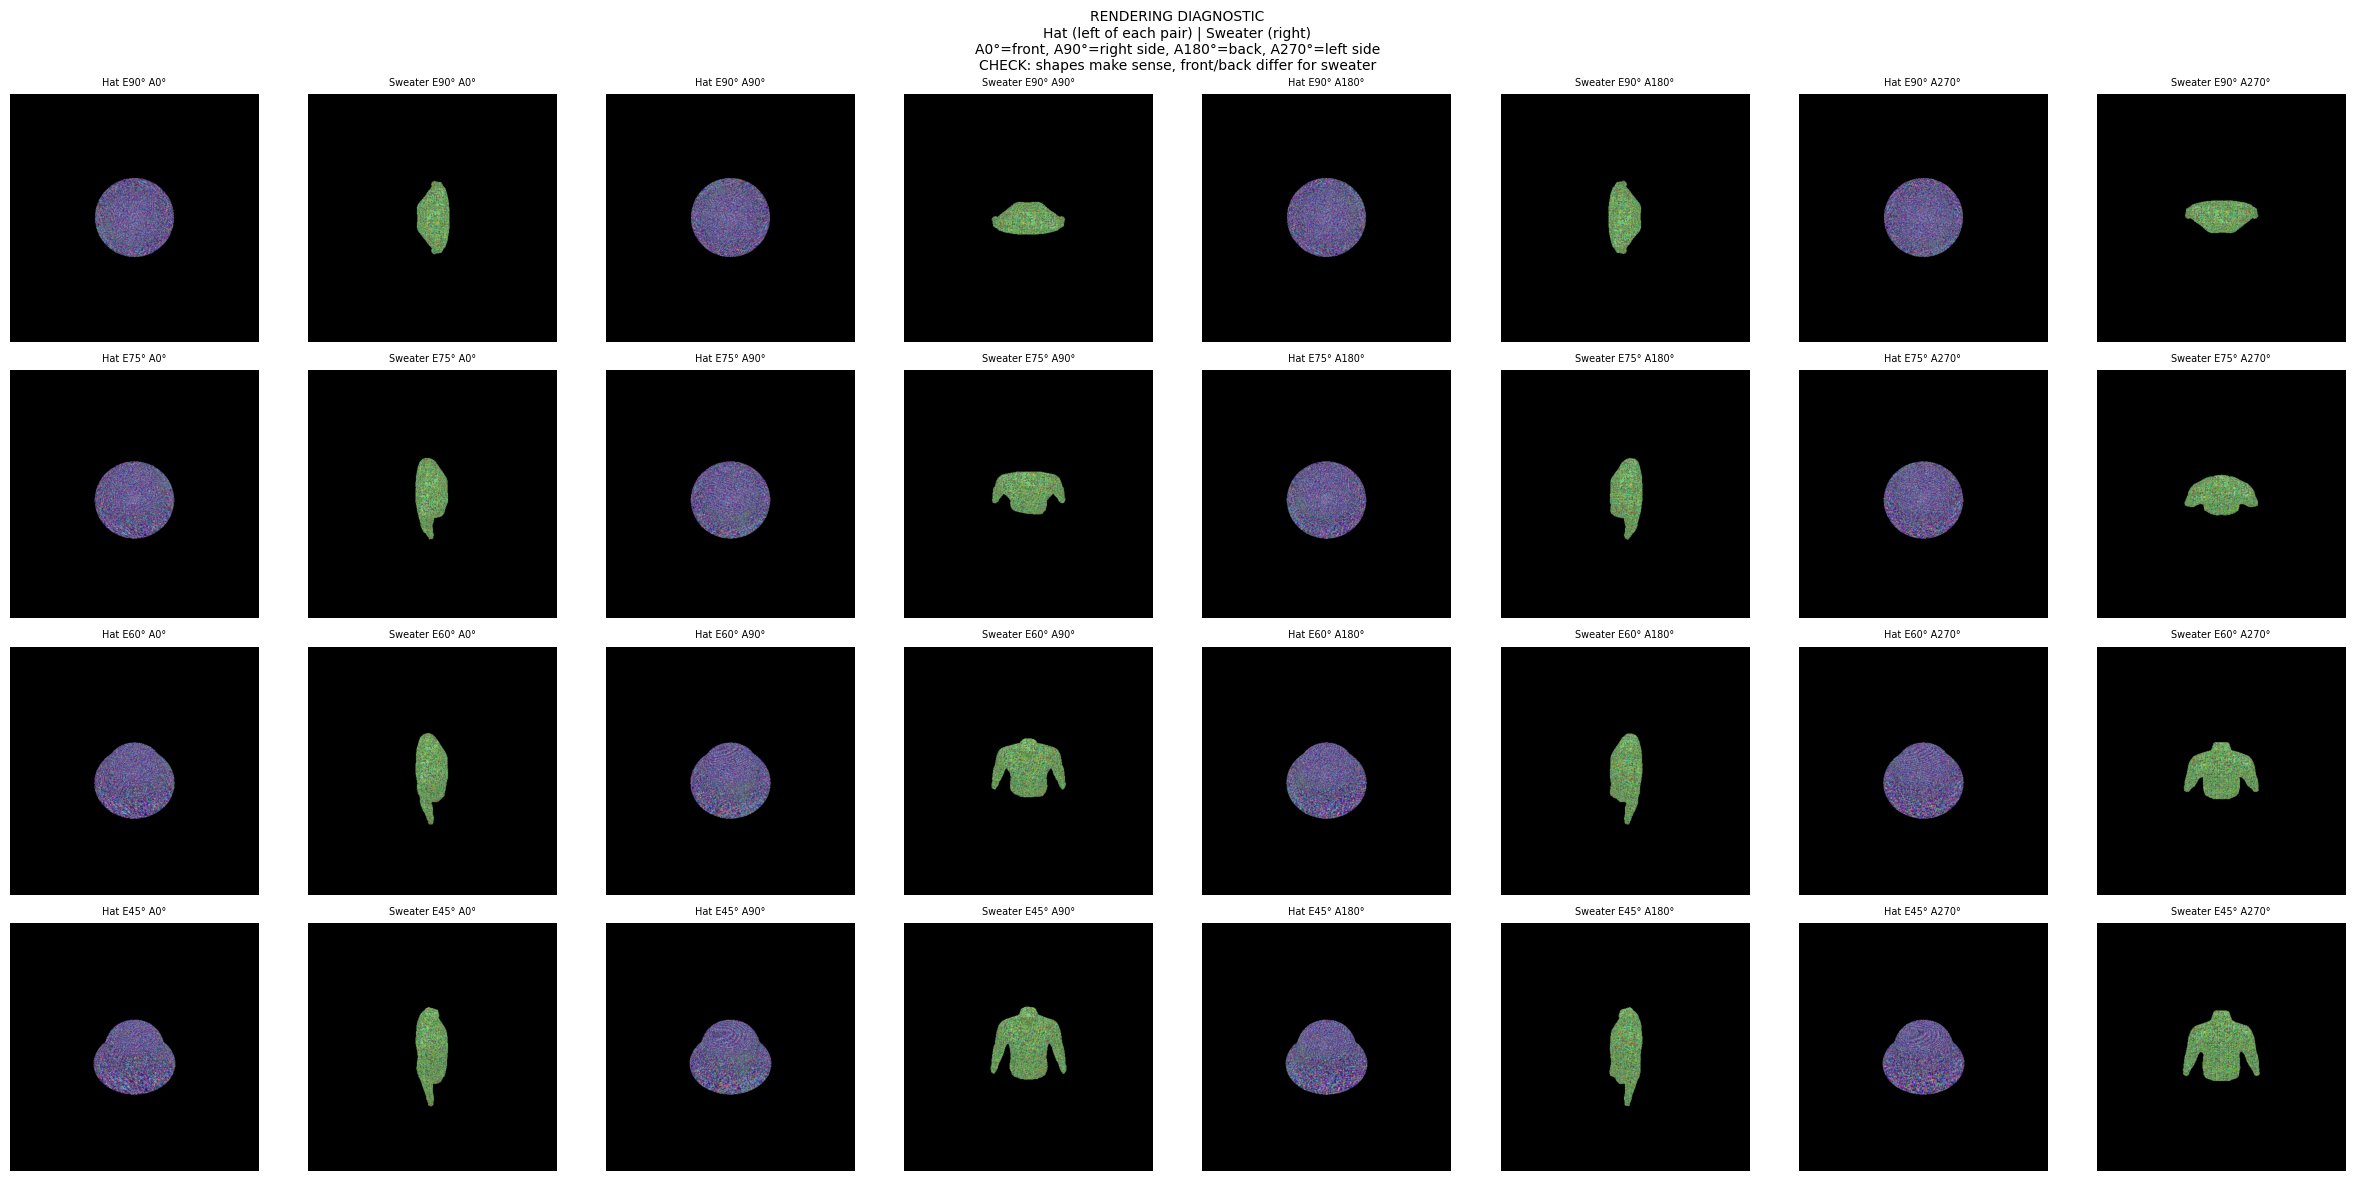

2026-03-18 01:54:54,990 | CHECK: Hat should look like a hat from all angles
2026-03-18 01:54:54,991 | CHECK: Sweater should show different shape at A0 (front) vs A180 (back)
2026-03-18 01:54:54,992 | CHECK: At E90 (overhead) you see mostly the top of both


In [6]:
class HatRenderer:
    
    def __init__(self, mesh_path, render_size=256, device='cuda'):
        self.device = device
        self.render_size = render_size
        self.training_mode = False
        #Load mesh - getting the verts, faces, and uv mappings
        self.mesh_loaded = False
        """
        CORRECT VERSION:
        if Path(mesh_path).exists():
            verts, faces, aux = load_obj(mesh_path, device=device)
            self.verts = verts
            self.faces = faces.verts_idx
            self.verts_uvs = aux.verts_uvs
            self.faces_uvs = faces.textures_idx
            self.mesh_loaded = True
            logger.info(f"Loaded mesh: {len(verts)} verts, {len(self.faces)} faces")
        """
        if Path(mesh_path).exists():
            verts, faces, aux = load_obj(mesh_path, device=device)
            center = (verts.max(0)[0] + verts.min(0)[0]) / 2
            verts = verts - center
            max_extent = (verts.max(0)[0] - verts.min(0)[0]).max()
            verts = verts / max_extent  # now fits in [-0.5, 0.5]
            self.verts = verts
            self.faces = faces.verts_idx
            self.verts_uvs = aux.verts_uvs
            self.faces_uvs = faces.textures_idx
            self.mesh_loaded = True
            logger.info(f"Loaded mesh: {len(verts)} verts, {len(self.faces)} faces (normalized from {max_extent:.1f} units)")
        else:
            #Use the placeholder
            logger.warning(f"Mesh not found at {mesh_path}. Using placeholder.")
            self._create_placeholder_mesh()
        #Rasterization settings
        self.raster_settings = RasterizationSettings(
            image_size=render_size, 
            blur_radius=0,
            faces_per_pixel=1
        )
        #Create rasterizer once
        self.rasterizer = MeshRasterizer(raster_settings=self.raster_settings)

    #Make a placeholder if we don't have a mesh which is a disk.
    def _create_placeholder_mesh(self):
        #Simple disk
        n_points = 32
        angles = torch.linspace(0, 2*np.pi, n_points+1)[:-1]
        #Vertices: center + rim
        verts = [[0, 0, 0]]  #center
        for a in angles:
            verts.append([torch.cos(a).item(), torch.sin(a).item(), 0])
        self.verts = torch.tensor(verts, dtype=torch.float32, device=self.device)
        #Faces: triangles from center to rim
        faces = []
        for i in range(n_points):
            faces.append([0, i + 1, (i + 1) % n_points + 1])
        self.faces = torch.tensor(faces, dtype=torch.int64, device=self.device)
        #UVs: simple radial mapping
        uvs = [[0.5, 0.5]]  # center
        for a in angles:
            uvs.append([0.5 + 0.5*torch.cos(a).item(), 0.5 + 0.5*torch.sin(a).item()])
        self.verts_uvs = torch.tensor(uvs, dtype=torch.float32, device=self.device)
        self.faces_uvs = self.faces.clone()
        self.mesh_loaded = True

    #Now we render the texture on the hat
    def render(self, texture, elevation=90, azimuth=0, scale=1.0, 
           gimbal_yaw=None, bearing=None, gimbal_pitch=None):
        batch_size = texture.shape[0]
        
        # Scale mesh vertices
        if isinstance(scale, (int, float)):
            verts = self.verts * scale
            verts_list = [verts] * batch_size
        elif isinstance(scale, torch.Tensor) and scale.dim() == 0:
            verts = self.verts * scale.item()
            verts_list = [verts] * batch_size
        else:
            verts_list = [self.verts * s.item() for s in scale]
        
        dist = 2.5
        
        if bearing is not None and gimbal_yaw is not None:
            # ══════════════════════════════════════════════════════════
            # DIRECT CAMERA from drone telemetry
            # Build R, T from gimbal_yaw + gimbal_pitch (real camera)
            # World: +X=East, +Y=Up, +Z=South (North=-Z)
            # ══════════════════════════════════════════════════════════
            if not isinstance(bearing, torch.Tensor):
                bearing = torch.tensor([bearing], device=self.device, dtype=torch.float32).expand(batch_size)
            elif bearing.dim() == 0:
                bearing = bearing.unsqueeze(0).expand(batch_size)
            if not isinstance(gimbal_yaw, torch.Tensor):
                gimbal_yaw = torch.tensor([gimbal_yaw], device=self.device, dtype=torch.float32).expand(batch_size)
            elif gimbal_yaw.dim() == 0:
                gimbal_yaw = gimbal_yaw.unsqueeze(0).expand(batch_size)
            if not isinstance(elevation, torch.Tensor):
                elevation = torch.tensor([elevation], device=self.device, dtype=torch.float32).expand(batch_size)
            elif elevation.dim() == 0:
                elevation = elevation.unsqueeze(0).expand(batch_size)
            
            brg_rad = bearing * (3.14159265 / 180.0)
            elev_rad = elevation * (3.14159265 / 180.0)
            gy_rad = gimbal_yaw * (3.14159265 / 180.0)
            
            # ── Eye position (from GPS bearing + geometric elevation) ──
            eye_x = dist * torch.cos(elev_rad) * torch.sin(brg_rad)
            eye_y = dist * torch.sin(elev_rad)
            eye_z = -dist * torch.cos(elev_rad) * torch.cos(brg_rad)
            eye = torch.stack([eye_x, eye_y, eye_z], dim=1)  # (B, 3)
            
            # ── Camera rotation from gimbal_yaw + gimbal_pitch ──
            # DJI gimbal: yaw=compass heading of camera, pitch=tilt (0=horiz, -90=down)
            # Roll=0 always (gimbal stabilized)
            if gimbal_pitch is not None:
                if not isinstance(gimbal_pitch, torch.Tensor):
                    gimbal_pitch = torch.tensor([gimbal_pitch], device=self.device, dtype=torch.float32).expand(batch_size)
                elif gimbal_pitch.dim() == 0:
                    gimbal_pitch = gimbal_pitch.unsqueeze(0).expand(batch_size)
                gp_rad = gimbal_pitch * (3.14159265 / 180.0)
            else:
                gp_rad = torch.tensor([-3.14159265/2], device=self.device).expand(batch_size)
            
            sin_gy = torch.sin(gy_rad)
            cos_gy = torch.cos(gy_rad)
            sin_gp = torch.sin(gp_rad)
            cos_gp = torch.cos(gp_rad)
            zeros = torch.zeros_like(sin_gy)
            
            # PyTorch3D camera: +X=left, +Y=up, +Z=forward (into screen)
            # Real camera axes in world space:
            #   forward = (cos(gp)*sin(gy), sin(gp), -cos(gp)*cos(gy))
            #   right   = (cos(gy), 0, sin(gy))
            #   up      = (-sin(gp)*sin(gy), cos(gp), sin(gp)*cos(gy))
            #
            # R transforms world→camera. R^T columns = camera axes in world.
            # Camera left = -right, Camera up = up, Camera forward = forward
            
            # R matrix: each row is a camera axis expressed in world coords
            # Row 0 (camera X = left):  (-cos(gy), 0, -sin(gy))
            # Row 1 (camera Y = up):    (-sin(gp)*sin(gy), cos(gp), sin(gp)*cos(gy))
            # Row 2 (camera Z = fwd):   (cos(gp)*sin(gy), sin(gp), -cos(gp)*cos(gy))
            
            R = torch.zeros(batch_size, 3, 3, device=self.device)
            R[:, 0, 0] = -cos_gy
            R[:, 0, 1] = zeros
            R[:, 0, 2] = -sin_gy
            R[:, 1, 0] = -sin_gp * sin_gy
            R[:, 1, 1] = cos_gp
            R[:, 1, 2] = sin_gp * cos_gy
            R[:, 2, 0] = cos_gp * sin_gy
            R[:, 2, 1] = sin_gp
            R[:, 2, 2] = -cos_gp * cos_gy
            
            # T = -R @ eye (translate so camera is at eye position)
            T = -torch.bmm(R, eye.unsqueeze(2)).squeeze(2)  # (B, 3)
        else:
            # Fallback: spherical coordinates (for diagnostic grids)
            if not isinstance(elevation, torch.Tensor):
                elevation = torch.tensor([elevation], device=self.device).expand(batch_size)
                azimuth = torch.tensor([azimuth], device=self.device).expand(batch_size)
            elif elevation.dim() == 0:
                elevation = elevation.unsqueeze(0).expand(batch_size)
                azimuth = azimuth.unsqueeze(0).expand(batch_size)
            R, T = look_at_view_transform(dist=dist, elev=elevation, azim=azimuth, device=self.device)
        
        cameras = FoVPerspectiveCameras(R=R, T=T, device=self.device)
        
        if self.training_mode:
            light_x = np.random.uniform(-1, 1)
            light_y = np.random.uniform(1, 3)
            light_z = np.random.uniform(-1, 1)
            lights = PointLights(
                device=self.device,
                location=[[light_x, light_y, light_z]],
                ambient_color=[[0.5, 0.5, 0.5]],
                diffuse_color=[[0.3, 0.3, 0.3]],
                specular_color=[[0.2, 0.2, 0.2]]
            )
        else:
            lights = PointLights(
                device=self.device,
                location=[[0.0, 2.0, 0.0]],
                ambient_color=[[0.85, 0.85, 0.85]],
                diffuse_color=[[0.1, 0.1, 0.1]],
                specular_color=[[0.05, 0.05, 0.05]]
            )
        
        shader = SoftPhongShader(device=self.device, cameras=cameras, lights=lights)
        tex_maps = texture.permute(0, 2, 3, 1)
        textures = TexturesUV(
            maps=tex_maps,
            faces_uvs=[self.faces_uvs] * batch_size,
            verts_uvs=[self.verts_uvs] * batch_size
        )
        meshes = Meshes(verts=verts_list, faces=[self.faces] * batch_size, textures=textures)
        fragments = self.rasterizer(meshes, cameras=cameras)
        images = shader(fragments, meshes, cameras=cameras, lights=lights)
        rendered_images = images[..., :3].permute(0, 3, 1, 2)
        alpha_masks = images[..., 3:4].permute(0, 3, 1, 2)
        alpha_masks = (alpha_masks > 0.1).float()
        return rendered_images, alpha_masks

def analyze_mesh_for_printing(mesh_path, config, preloaded=None):
    from collections import defaultdict, deque
    _p = config['printer']
    #Check if the mesh is here
    if not Path(mesh_path).exists():
        logger.warning("No mesh file — defaulting to 12x12 inch print area")
        config['physical_size_inches'] = (12.0, 12.0)
        config['texture_output_size_w'] = int(_p['dpi'] * 12)
        config['texture_output_size_h'] = int(_p['dpi'] * 12)
        config['uv_islands'] = []
        return
    #Check if we have already parsed the .obj
    if preloaded is not None:
        verts_np = preloaded['verts'].cpu().numpy()
        verts_uvs = preloaded['verts_uvs'].cpu().numpy()
        faces_verts = preloaded['faces_verts'].cpu().numpy()
        faces_uvs = preloaded['faces_uvs'].cpu().numpy()
    else:
        verts, faces, aux = load_obj(mesh_path)
        verts_np = verts.cpu().numpy()
        verts_uvs = aux.verts_uvs.cpu().numpy()
        faces_verts = faces.verts_idx.cpu().numpy()
        faces_uvs = faces.textures_idx.cpu().numpy()
    #Auto-callibration fallback
    if _p['mesh_unit_to_inches'] is None:
        x_span = verts_np[:, 0].max() - verts_np[:, 0].min()
        y_span = verts_np[:, 1].max() - verts_np[:, 1].min()
        z_span = verts_np[:, 2].max() - verts_np[:, 2].min()
        max_span = max(x_span, y_span, z_span)
        _p['mesh_unit_to_inches'] = 10.0 / max_span if max_span > 0 else 1.0
        logger.warning(f"Auto-estimated mesh scale: {_p['mesh_unit_to_inches']:.3f} in/unit " f"(mesh widest: {max_span:.3f} units -> ~10 inches)")
        logger.warning("SET printer.mesh_unit_to_inches manually for accuracy")
    scale = _p['mesh_unit_to_inches']
    #Adjacency map
    uv_vert_to_faces = defaultdict(set)
    for fi, face in enumerate(faces_uvs):
        for vi in face:
            uv_vert_to_faces[vi].add(fi)
    #BFS
    visited = set()
    islands = []
    for fi in range(len(faces_uvs)):
        if fi in visited:
            continue
        island = []
        queue = deque([fi])
        while queue:
            f = queue.popleft()
            if f in visited:
                continue
            visited.add(f)
            island.append(f)
            for vi in faces_uvs[f]:
                for neighbor in uv_vert_to_faces[vi]:
                    if neighbor not in visited:
                        queue.append(neighbor)
        islands.append(island)
    #Measure the size of the islands
    island_info = []
    for idx, island_faces in enumerate(islands):
        island_uv_indices = set()
        for fi in island_faces:
            for vi in faces_uvs[fi]:
                island_uv_indices.add(vi)
        island_uvs_arr = verts_uvs[list(island_uv_indices)]
        u_min, v_min = island_uvs_arr.min(axis=0)
        u_max, v_max = island_uvs_arr.max(axis=0)
        #Triangle area via cross product - sum the area
        total_area_3d = 0.0
        for fi in island_faces:
            v0 = verts_np[faces_verts[fi][0]]
            v1 = verts_np[faces_verts[fi][1]]
            v2 = verts_np[faces_verts[fi][2]]
            total_area_3d += 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        #Ratio between 3D surface and UV area
        physical_area = total_area_3d * (scale ** 2)
        #Store measurements on the islands
        island_info.append({
            'index': idx,
            'num_faces': len(island_faces),
            'uv_bounds': (u_min, v_min, u_max, v_max),
            'physical_area_sq_inches': physical_area,
        })
        logger.info(f"  Island {idx}: {len(island_faces)} faces, ~{physical_area:.1f} sq in")
    #Overall print dimensions
    config['uv_islands'] = island_info
    logger.info(f"Found {len(islands)} UV island(s)")
    #Total area
    total_area = sum(i['physical_area_sq_inches'] for i in island_info)
    all_u_min = min(i['uv_bounds'][0] for i in island_info)
    all_v_min = min(i['uv_bounds'][1] for i in island_info)
    all_u_max = max(i['uv_bounds'][2] for i in island_info)
    all_v_max = max(i['uv_bounds'][3] for i in island_info)
    uv_width = all_u_max - all_u_min
    uv_height = all_v_max - all_v_min
    #Bounding box uv area for printing
    sa = _p['seam_allowance_inches']
    #Average 3D-to-UV scale: compare total 3D area to total UV area
    total_uv_area = 0.0
    for island_faces_idx in islands:
        for fi in island_faces_idx:
            uv0 = verts_uvs[faces_uvs[fi][0]]
            uv1 = verts_uvs[faces_uvs[fi][1]]
            uv2 = verts_uvs[faces_uvs[fi][2]]
            total_uv_area += 0.5 * abs(np.cross(uv1 - uv0, uv2 - uv0))
    #physical_area / uv_area = (scale_per_uv_unit)^2
    scale_per_uv = np.sqrt(total_area / (total_uv_area + 1e-8))
    phys_w = uv_width * scale_per_uv + 2 * sa
    phys_h = uv_height * scale_per_uv + 2 * sa
    #Store info
    config['physical_size_inches'] = (phys_w, phys_h)
    config['texture_output_size_w'] = int(_p['dpi'] * phys_w)
    config['texture_output_size_h'] = int(_p['dpi'] * phys_h)
    #Log the info
    logger.info(f"Print size: {phys_w:.1f} x {phys_h:.1f} inches " f"({config['texture_output_size_w']}x{config['texture_output_size_h']}px @ {_p['dpi']} DPI)")

# ── Instantiate both renderers ──
renderer_hat = HatRenderer(CONFIG['mesh_path'], CONFIG['render_size'], device)
renderer_sweater = HatRenderer(CONFIG['sweater_mesh_path'], CONFIG['render_size'], device)

# ── Analyze both for printing ──
if renderer_hat.mesh_loaded and Path(CONFIG['mesh_path']).exists():
    analyze_mesh_for_printing(CONFIG['mesh_path'], CONFIG, preloaded={
        'verts': renderer_hat.verts, 'verts_uvs': renderer_hat.verts_uvs,
        'faces_verts': renderer_hat.faces, 'faces_uvs': renderer_hat.faces_uvs,
    })

# Store sweater print info under separate keys
sweater_config = {**CONFIG, 'printer': CONFIG['printer'].copy()}
if renderer_sweater.mesh_loaded and Path(CONFIG['sweater_mesh_path']).exists():
    analyze_mesh_for_printing(CONFIG['sweater_mesh_path'], sweater_config, preloaded={
        'verts': renderer_sweater.verts, 'verts_uvs': renderer_sweater.verts_uvs,
        'faces_verts': renderer_sweater.faces, 'faces_uvs': renderer_sweater.faces_uvs,
    })
CONFIG['sweater_physical_size_inches'] = sweater_config.get('physical_size_inches', (12, 12))
CONFIG['sweater_texture_output_size_w'] = sweater_config.get('texture_output_size_w', 3600)
CONFIG['sweater_texture_output_size_h'] = sweater_config.get('texture_output_size_h', 3600)

# ══════════════════════════════════════════════════════════════
# RENDERING DIAGNOSTIC — verify both meshes look correct
# ══════════════════════════════════════════════════════════════
logger.info("Running rendering diagnostic...")
diag_elevs = [90, 75, 60, 45]
diag_azims = [0, 90, 180, 270]

fig, axes = plt.subplots(len(diag_elevs), len(diag_azims) * 2, 
                          figsize=(len(diag_azims) * 6, len(diag_elevs) * 3))

with torch.no_grad():
    rand_hat_tex = generator_hat.generate(batch_size=1)
    rand_sw_tex = generator_sweater.generate(batch_size=1)
    
    for row, elev in enumerate(diag_elevs):
        for col, azim in enumerate(diag_azims):
            # Hat
            rh, ah = renderer_hat.render(rand_hat_tex, elevation=elev, azimuth=azim, scale=1.0)
            vis_h = rh * ah
            axes[row, col * 2].imshow(vis_h[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes[row, col * 2].set_title(f'Hat E{elev}° A{azim}°', fontsize=7)
            axes[row, col * 2].axis('off')
            
            # Sweater
            rs, as_ = renderer_sweater.render(rand_sw_tex, elevation=elev, azimuth=azim, scale=1.0)
            vis_s = rs * as_
            axes[row, col * 2 + 1].imshow(vis_s[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes[row, col * 2 + 1].set_title(f'Sweater E{elev}° A{azim}°', fontsize=7)
            axes[row, col * 2 + 1].axis('off')

fig.suptitle('RENDERING DIAGNOSTIC\nHat (left of each pair) | Sweater (right)\n'
             'A0°=front, A90°=right side, A180°=back, A270°=left side\n'
             'CHECK: shapes make sense, front/back differ for sweater', fontsize=10)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/rendering_diagnostic.png", dpi=150, bbox_inches='tight')
plt.show()
logger.info("CHECK: Hat should look like a hat from all angles")
logger.info("CHECK: Sweater should show different shape at A0 (front) vs A180 (back)")
logger.info("CHECK: At E90 (overhead) you see mostly the top of both")

## 8: T-SEA Augmentations

Helper methods for black/gray/white box transfers

In [7]:
#Randomly mask a region of the rendered hat. Prevents overfitting to specific texture patterns.
def patch_cutout(rendered_hat, alpha_mask, prob=0.9, ratio=0.4, fill=0.5):
    if np.random.random() > prob:
        return rendered_hat
    B, C, H, W = rendered_hat.shape
    #Random cutout size
    cut_h = int(H * ratio)
    cut_w = int(W * ratio)
    #Random position
    top = np.random.randint(0, H - cut_h + 1)
    left = np.random.randint(0, W - cut_w + 1)
    #Apply cutout (only where alpha > 0)
    mask = alpha_mask.clone()
    mask[:, :, top:top+cut_h, left:left+cut_w] = 0
    rendered_hat = rendered_hat * mask + fill * (1 - mask) * (alpha_mask > 0).float()
    return rendered_hat

#Mild augmentations that don't distort the image too much.
def constrained_augmentation(image):
    B, C, H, W = image.shape
    #Random scale (0.9 - 1.1)
    scale = np.random.uniform(0.9, 1.1)
    new_h = int(H * scale)
    new_w = int(W * scale)
    image = F.interpolate(image, size=(new_h, new_w), mode='bilinear', align_corners=False)
    #Crop/pad back to original size
    if new_h > H:
        start_h = (new_h - H) // 2
        start_w = (new_w - W) // 2
        image = image[:, :, start_h:start_h+H, start_w:start_w+W]
    else:
        pad_h_top = (H - new_h) // 2
        pad_h_bot = H - new_h - pad_h_top
        pad_w_left = (W - new_w) // 2
        pad_w_right = W - new_w - pad_w_left
        image = F.pad(image, [pad_w_left, pad_w_right, pad_h_top, pad_h_bot], mode='reflect')
    #Color jitter (mild)
    brightness = np.random.uniform(0.9, 1.1)
    image = image * brightness
    #Random horizontal flip
    if np.random.random() > 0.5:
        image = torch.flip(image, dims=[3])
    return image.clamp(0, 1)

#ShakeDrop reates virtual ensemble of model variants
def shakedrop_forward(x, drop_prob=0.5, alpha_range=(0, 2)):
    #Simplified ShakeDrop: add scaled noise to create virtual ensemble variants
    if np.random.random() < drop_prob:
        alpha = np.random.uniform(*alpha_range)
        noise = torch.randn_like(x) * 0.1 * alpha
        x = x + noise
    return x

## 9: URAdv Augmentations

For better performance under drone conditions

In [8]:
#Add simulated light reflections on the hat surface.
def add_light_spots(image, alpha_mask, num_range=(0, 3), intensity_range=(0.1, 0.4)):
    if np.random.random() > 0.5:
        return image
    B, C, H, W = image.shape
    num_spots = np.random.randint(*num_range)
    y, x = torch.meshgrid(torch.arange(H, device=image.device), torch.arange(W, device=image.device), indexing='ij')
    for _ in range(num_spots):
        #Random spot position (within hat region)
        cy = np.random.randint(H // 4, 3 * H // 4)
        cx = np.random.randint(W // 4, 3 * W // 4)
        #Spot parameters
        radius = np.random.uniform(0.05, 0.15) * min(H, W)
        intensity = np.random.uniform(*intensity_range)
        #Create Gaussian spot
        dist = ((x - cx) ** 2 + (y - cy) ** 2).float()
        spot = torch.exp(-dist / (2 * radius ** 2)) * intensity
        #Apply only within hat (where alpha > 0)
        spot = spot.unsqueeze(0).unsqueeze(0) * (alpha_mask > 0).float()
        image = image + spot
    return image.clamp(0, 1)

#Add simulated shadows on the hat surface.
def add_shadows(image, alpha_mask, num_range=(0, 2), opacity_range=(0.2, 0.5)):
    if np.random.random() > 0.5:
        return image
    B, C, H, W = image.shape
    num_shadows = np.random.randint(*num_range)
    y, x = torch.meshgrid(torch.arange(H, device=image.device), torch.arange(W, device=image.device), indexing='ij')
    for _ in range(num_shadows):
        #Random shadow as diagonal stripe
        angle = np.random.uniform(0, np.pi)
        opacity = np.random.uniform(*opacity_range)
        width = np.random.uniform(0.1, 0.3) * min(H, W)
        #Create shadow mask
        offset = np.random.uniform(0, H)
        dist = torch.abs(x * np.cos(angle) + y * np.sin(angle) - offset)
        shadow = (dist < width).float() * opacity
        #Apply only within hat
        shadow = shadow.unsqueeze(0).unsqueeze(0) * (alpha_mask > 0).float()
        image = image * (1 - shadow)
    return image.clamp(0, 1)

#Simulate printer color/brightness variation.
def simulate_printing(texture, mul_std=0.1, add_std=0.05):
    #Multiplicative noise
    mul_noise = torch.randn_like(texture) * mul_std + 1.0
    texture = texture * mul_noise
    #Additive noise
    add_noise = torch.randn_like(texture) * add_std
    texture = texture + add_noise
    return texture.clamp(0, 1)

class PrinterGamut:

    #Load parameters, or use simplified constraints
    def __init__(self, config, device='cuda'):
        self.config = config['printer']
        self.device = device
        gamut_path = self.config.get('gamut_samples_path')
        if gamut_path and Path(gamut_path).exists():
            self.gamut_samples = torch.from_numpy(np.load(gamut_path)).float().to(self.device)
            self.use_measured_gamut = True
            logger.info(f"Loaded {len(self.gamut_samples)} gamut samples")
        else:
            self.use_measured_gamut = False
            logger.info("Using simplified gamut constraints")

    #Non-printability score loss
    def nps_loss(self, texture):
        loss = 0.0
        if self.use_measured_gamut:
            #Compare each texture pixel to the nearest printable color
            #texture: (B, 3, H, W) -> (N, 3) flat pixel list
            B, C, H, W = texture.shape
            pixels = texture.permute(0, 2, 3, 1).reshape(-1, 3)  #(N, 3)
            #gamut_samples: (G, 3) — measured printable RGB values
            #Compute distance from each pixel to nearest gamut sample
            chunk_size = 4096
            gamut_dists = []
            for i in range(0, pixels.shape[0], chunk_size):
                chunk = pixels[i:i+chunk_size]  #(chunk, 3)
                dists = torch.cdist(chunk.unsqueeze(0), self.gamut_samples.unsqueeze(0)).squeeze(0)  #(chunk, G)
                min_dists = dists.min(dim=1)[0]  #(chunk,)
                gamut_dists.append(min_dists)
            gamut_dists = torch.cat(gamut_dists)
            loss = loss + gamut_dists.mean()
        else:
            #Simplified constraints when no gamut data available
            max_ch = texture.max(dim=1)[0]
            min_ch = texture.min(dim=1)[0]
            saturation = (max_ch - min_ch) / (max_ch + 1e-8)
            brightness = max_ch
            #Saturation * brightness threshold
            loss = loss + F.relu(saturation * brightness - self.config['nps_threshold']).mean()
            #Saturation cap
            loss = loss + F.relu(saturation - self.config['max_saturation']).mean()
            #Brightness bounds
            loss = loss + F.relu(brightness - self.config['max_brightness']).mean()
            loss = loss + F.relu(self.config['min_brightness'] - brightness).mean()
        return loss

    #Hard clamp for final export
    def clamp_to_gamut(self, texture):
        return texture.clamp(self.config['min_brightness'], self.config['max_brightness'])

#Initialize globally
printer_gamut = PrinterGamut(CONFIG, device)

#Apply camera artifacts: blur, noise.
def apply_environmental_augmentation(image, prob=0.3):
    #Motion blur
    if np.random.random() < prob:
        kernel_size = np.random.choice([3, 5, 7])
        kernel = torch.zeros(kernel_size, kernel_size, device=image.device)
        kernel[kernel_size//2, :] = 1.0 / kernel_size
        #Rotate kernel to random angle for directional blur
        angle = np.random.uniform(0, 360)
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        #Build rotation matrix and affine grid
        theta = torch.tensor([[cos_a, -sin_a, 0], [sin_a,  cos_a, 0]], dtype=torch.float32, device=image.device).unsqueeze(0)
        grid = F.affine_grid(theta, [1, 1, kernel_size, kernel_size], align_corners=False)
        kernel_rotated = F.grid_sample(kernel.unsqueeze(0).unsqueeze(0), grid, align_corners=False, mode='bilinear', padding_mode='zeros').squeeze()
        #Renormalize so kernel sums to 1
        kernel_rotated = kernel_rotated / (kernel_rotated.sum() + 1e-8)
        image = F.conv2d(image, kernel_rotated.view(1, 1, kernel_size, kernel_size).expand(3, 1, -1, -1), padding=kernel_size//2, groups=3)
    #Gaussian noise
    if np.random.random() < prob:
        noise_std = np.random.uniform(0.01, 0.05)
        image = image + torch.randn_like(image) * noise_std
    return image.clamp(0, 1)

#Viewpoint jitter for robustness
def apply_viewpoint_jitter(elevation, azimuth, scale, pitch_jitter, heading_jitter, scale_jitter):
    """Per-surface viewpoint jitter. Hat uses wide heading jitter (symmetric),
    sweater uses narrow heading jitter (front ≠ back)."""
    elev = elevation + np.random.uniform(-pitch_jitter, pitch_jitter)
    elev = np.clip(elev, 0, 90)
    azim = azimuth + np.random.uniform(-heading_jitter, heading_jitter)
    azim = azim % 360
    scl = scale * (1 + np.random.uniform(-scale_jitter, scale_jitter))
    scl = np.clip(scl, 0.1, 2.0)
    return elev, azim, scl

def apply_random_blur(rendered_hat, alpha_mask, prob=0.5, sigma_range=(0.5, 2.0)):
    if np.random.random() > prob:
        return rendered_hat
    sigma = np.random.uniform(*sigma_range)
    #Kernel size must be odd, ~3x sigma
    ksize = int(np.ceil(sigma * 3)) * 2 + 1
    ksize = max(3, ksize)
    #Gaussian kernel
    x = torch.arange(ksize, device=rendered_hat.device).float() - ksize // 2
    kernel_1d = torch.exp(-x**2 / (2 * sigma**2))
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.view(1, 1, ksize, ksize).expand(3, 1, -1, -1)
    #Apply only to hat region
    blurred = F.conv2d(rendered_hat, kernel_2d, padding=ksize//2, groups=3)
    #Blend: blur only where alpha > 0
    hat_region = (alpha_mask > 0.1).float()
    rendered_hat = blurred * hat_region + rendered_hat * (1 - hat_region)
    return rendered_hat

def frequency_bottleneck(texture, bottleneck_size):
    orig_size = texture.shape[-1]
    if bottleneck_size >= orig_size:
        return texture
    low = F.interpolate(texture, size=(bottleneck_size, bottleneck_size), mode='bilinear', align_corners=False)
    restored = F.interpolate(low, size=(orig_size, orig_size), mode='bilinear', align_corners=False)
    return restored

def get_bottleneck_size(epoch, config):
    schedule = config['freq_bottleneck']['stage1']
    size = schedule[0][1]  #default to first
    for start_epoch, bn_size in schedule:
        if epoch >= start_epoch:
            size = bn_size
    return size

2026-03-18 01:54:55,050 | Using simplified gamut constraints


## 10: Toroidal Cropping

Wrapping the texture

In [9]:
#Try to get smooth textures
def total_variation_loss(texture):
    diff_h = texture[:, :, 1:, :] - texture[:, :, :-1, :]
    diff_w = texture[:, :, :, 1:] - texture[:, :, :, :-1]
    #Toroidal wrap: penalize top↔bottom and left↔right seam
    diff_h_wrap = texture[:, :, 0:1, :] - texture[:, :, -1:, :]
    diff_w_wrap = texture[:, :, :, 0:1] - texture[:, :, :, -1:]
    #Concatenate so all pairs have equal weight in the mean
    all_h = torch.cat([diff_h, diff_h_wrap], dim=2)
    all_w = torch.cat([diff_w, diff_w_wrap], dim=3)
    return (all_h.pow(2).mean() + all_w.pow(2).mean()) / 2

class ToroidalLatent(nn.Module):

    def __init__(self, local_size, crop_size=9, latent_channels=128, device='cuda'):
        super().__init__()
        self.local_size = local_size
        self.crop_size = crop_size
        self.latent_channels = latent_channels
        self.z_local = nn.Parameter(torch.randn(1, latent_channels, local_size, local_size, device=device) * 0.1)

    #Random crop
    def get_random_crops(self, batch_size):
        #Tile 3x3 for wraparound
        z_tiled = self.z_local.repeat(1, 1, 3, 3)
        crops = []
        for _ in range(batch_size):
            #Random offset within middle tile (to enable wraparound)
            i = np.random.randint(self.local_size, 2 * self.local_size)
            j = np.random.randint(self.local_size, 2 * self.local_size)
            crop = z_tiled[:, :, i:i+self.crop_size, j:j+self.crop_size]
            crops.append(crop)
        return torch.cat(crops, dim=0)

    #Crop to fill size
    def get_full_latent(self, target_spatial_size):
        reps = (target_spatial_size + self.local_size - 1) // self.local_size + 1
        z_tiled = self.z_local.repeat(1, 1, reps, reps)
        return z_tiled[:, :, :target_spatial_size, :target_spatial_size]

    #Deterministic crop
    def get_canonical_crop(self):
        offset = (self.local_size - self.crop_size) // 2
        return self.z_local[:, :, offset:offset+self.crop_size, offset:offset+self.crop_size]

## 11: Sceen Composition

Render the sceen (put hat on image)

In [10]:
import math

def _composite_single_surface(scene_image, mask, rendered, alpha):
    """Composite rendered surface onto scene.
    
    The RENDERER determines the shape (via alpha).
    The MASK only determines position (centroid) and size (pixel area).
    This preserves the 3D perspective — what the camera would actually see.
    """
    B, C, H, W = scene_image.shape
    result = scene_image.clone()
    
    for i in range(B):
        m = mask[i, 0]
        if m.sum() == 0:
            continue
        
        a = alpha[i, 0]
        a_ys, a_xs = torch.where(a > 0.1)
        if len(a_ys) == 0:
            continue
        
        # ── FROM MASK: position and size only ──
        m_ys, m_xs = torch.where(m > 0.5)
        if len(m_ys) == 0:
            continue
        m_cy = m_ys.float().mean().item()
        m_cx = m_xs.float().mean().item()
        mask_area = len(m_ys)
        
        # ── FROM RENDERER: crop to non-transparent region ──
        ay1, ay2 = a_ys.min().item(), a_ys.max().item()
        ax1, ax2 = a_xs.min().item(), a_xs.max().item()
        r_crop = rendered[i:i+1, :, ay1:ay2+1, ax1:ax2+1]
        a_crop = alpha[i:i+1, :, ay1:ay2+1, ax1:ax2+1]
        rh, rw = r_crop.shape[2], r_crop.shape[3]
        
        # ── SCALE: match mask area, uniform (preserves 3D shape) ──
        render_area = (a_crop > 0.1).float().sum().item()
        if render_area < 1:
            continue
        s = math.sqrt(mask_area / render_area)
        new_h = max(int(rh * s), 1)
        new_w = max(int(rw * s), 1)
        
        r_scaled = F.interpolate(r_crop, size=(new_h, new_w),
                                  mode='bilinear', align_corners=False)
        a_scaled = F.interpolate(a_crop, size=(new_h, new_w),
                                  mode='bilinear', align_corners=False)
        
        # ── PLACE: centered on mask centroid ──
        py1 = int(m_cy - new_h / 2)
        px1 = int(m_cx - new_w / 2)
        
        # Clip to image bounds
        sy1 = max(0, -py1)
        sx1 = max(0, -px1)
        sy2 = min(new_h, H - py1)
        sx2 = min(new_w, W - px1)
        dy1 = max(0, py1)
        dx1 = max(0, px1)
        dy2 = dy1 + (sy2 - sy1)
        dx2 = dx1 + (sx2 - sx1)
        
        if dy2 <= dy1 or dx2 <= dx1:
            continue
        
        r_patch = r_scaled[:, :, sy1:sy2, sx1:sx2]
        a_patch = a_scaled[:, :, sy1:sy2, sx1:sx2]
        
        # ── BLEND: rendered alpha ONLY — mask does NOT clip shape ──
        result[i:i+1, :, dy1:dy2, dx1:dx2] = (
            r_patch * a_patch +
            result[i:i+1, :, dy1:dy2, dx1:dx2] * (1 - a_patch)
        )
    
    return result


def composite_hat_on_scene(scene_image, hat_mask, rendered_hat, alpha_mask):
    """Backward-compatible wrapper — composites single surface."""
    return _composite_single_surface(scene_image, hat_mask, rendered_hat, alpha_mask)


def composite_dual_on_scene(scene, hat_mask, sweater_mask,
                            rendered_hat, hat_alpha,
                            rendered_sweater, sweater_alpha,
                            hat_usable, sweater_usable):
    """Composite both surfaces: sweater FIRST (body), hat SECOND (head)."""
    result = scene.clone()
    B = scene.shape[0]
    
    # Sweater first
    sw_mask_batch = sweater_mask.clone()
    for i in range(B):
        if not sweater_usable[i]:
            sw_mask_batch[i] = 0
    result = _composite_single_surface(result, sw_mask_batch, rendered_sweater, sweater_alpha)
    
    # Hat second (on top)
    hat_mask_batch = hat_mask.clone()
    for i in range(B):
        if not hat_usable[i]:
            hat_mask_batch[i] = 0
    result = _composite_single_surface(result, hat_mask_batch, rendered_hat, hat_alpha)
    
    return result

def crop_to_person(composited, person_bbox, target_size=640, pad_ratio=0.5):
    B, C, H, W = composited.shape
    crops = []
    for i in range(B):
        x1, y1, x2, y2 = person_bbox[i]
        bw, bh = x2 - x1, y2 - y1
        side = max(bw, bh) * (1 + pad_ratio)
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        half = side / 2
        cx1 = int(torch.clamp(cx - half, min=0))
        cy1 = int(torch.clamp(cy - half, min=0))
        cx2 = int(torch.clamp(cx + half, max=W))
        cy2 = int(torch.clamp(cy + half, max=H))
        crop = composited[i:i+1, :, cy1:cy2, cx1:cx2]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
        crops.append(crop)
    return torch.cat(crops, dim=0)

def sahi_aware_crop(composited, person_bbox, config):
    B, C, H, W = composited.shape
    slice_size = config.get('sahi_slice_size', 960)
    target_size = config['detector_input_size']
    crops = []
    for i in range(B):
        bbox = person_bbox[i]
        cx = (bbox[0] + bbox[2]).item() / 2
        cy = (bbox[1] + bbox[3]).item() / 2
        bw = (bbox[2] - bbox[0]).item()
        bh = (bbox[3] - bbox[1]).item()
        person_side = max(bw, bh)
        r = np.random.random()
        if r < 0.7:
            #SAHI-scale: ~960 tile with ±15% variation
            crop_size = int(slice_size * np.random.uniform(0.85, 1.15))
        elif r < 0.9:
            #Medium: 2-4× person bbox
            crop_size = int(person_side * np.random.uniform(2.0, 4.0))
        else:
            #Tight: 1.5× person bbox (original crop_to_person)
            crop_size = int(person_side * 1.5)
        crop_size = max(min(crop_size, H, W), 64)
        #Random position with person inside (not centered)
        margin = crop_size * 0.05
        x_lo = max(0, cx - crop_size + margin)
        x_hi = min(W - crop_size, cx - margin)
        y_lo = max(0, cy - crop_size + margin)
        y_hi = min(H - crop_size, cy - margin)
        x1 = int(np.clip(np.random.uniform(x_lo, max(x_hi, x_lo + 1)), 0, W - crop_size))
        y1 = int(np.clip(np.random.uniform(y_lo, max(y_hi, y_lo + 1)), 0, H - crop_size))
        crop = composited[i:i+1, :, y1:y1+crop_size, x1:x1+crop_size]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
        crops.append(crop)
    return torch.cat(crops, dim=0)

def multi_tile_crop(composited, person_bbox, config, num_tiles=3):
    B, C, H, W = composited.shape
    slice_size = config.get('sahi_slice_size', 960)
    target_size = config['detector_input_size']
    all_crops = []
    for i in range(B):
        bbox = person_bbox[i]
        cx = (bbox[0] + bbox[2]).item() / 2
        cy = (bbox[1] + bbox[3]).item() / 2
        person_side = max((bbox[2] - bbox[0]).item(), (bbox[3] - bbox[1]).item())
        tiles = []
        for t in range(num_tiles):
            r = np.random.random()
            if r < 0.5:
                #SAHI-scale tile
                crop_size = int(slice_size * np.random.uniform(0.85, 1.15))
            elif r < 0.8:
                #Fullframe-like (whole image downscaled = large crop)
                crop_size = int(min(H, W) * np.random.uniform(0.7, 1.0))
            else:
                #Medium
                crop_size = int(person_side * np.random.uniform(2.0, 4.0))
            crop_size = max(min(crop_size, H, W), 64)
            #Random position with person inside
            margin = crop_size * 0.05
            x_lo = max(0, cx - crop_size + margin)
            x_hi = min(W - crop_size, cx - margin)
            y_lo = max(0, cy - crop_size + margin)
            y_hi = min(H - crop_size, cy - margin)
            x1 = int(np.clip(np.random.uniform(x_lo, max(x_hi, x_lo + 1)), 0, W - crop_size))
            y1 = int(np.clip(np.random.uniform(y_lo, max(y_hi, y_lo + 1)), 0, H - crop_size))
            crop = composited[i:i+1, :, y1:y1+crop_size, x1:x1+crop_size]
            crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
            tiles.append(crop)
        all_crops.extend(tiles)
    return torch.cat(all_crops, dim=0) # (B*num_tiles, 3, 640, 640)

def crop_to_head(composited, person_bbox, hat_mask, target_size=640):
    B, C, H, W = composited.shape
    crops = []
    for i in range(B):
        mask = hat_mask[i, 0]
        if mask.sum() < 10:
            #Fallback to top 25% of person bbox
            x1, y1, x2, y2 = person_bbox[i]
            bh = y2 - y1
            head_y2 = y1 + bh * 0.25
        else:
            ys, xs = torch.where(mask > 0.5)
            y1, y2 = ys.min(), ys.max()
            x1, x2 = xs.min(), xs.max()
            head_y2 = y2
        #Square crop centered on hat with some context
        x1_p, y1_p, x2_p, y2_p = person_bbox[i]
        hat_cx = (x1 + x2) / 2 if mask.sum() >= 10 else (x1_p + x2_p) / 2
        hat_cy = (y1 + head_y2) / 2 if mask.sum() >= 10 else y1_p + (y2_p - y1_p) * 0.125
        bw = x2_p - x1_p
        side = max(bw * 0.6, 100)  # head-width crop with context
        half = side / 2
        cx1 = int(torch.clamp(hat_cx - half, min=0))
        cy1 = int(torch.clamp(hat_cy - half, min=0))
        cx2 = int(torch.clamp(hat_cx + half, max=W))
        cy2 = int(torch.clamp(hat_cy + half, max=H))
        crop = composited[i:i+1, :, cy1:cy2, cx1:cx2]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='bilinear', align_corners=False)
        crops.append(crop)
    return torch.cat(crops, dim=0)

def crop_hat_mask(hat_mask, person_bbox, target_size=640, pad_ratio=0.5):
    B, C, H, W = hat_mask.shape
    crops = []
    for i in range(B):
        x1, y1, x2, y2 = person_bbox[i]
        bw, bh = x2 - x1, y2 - y1
        side = max(bw, bh) * (1 + pad_ratio)
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        half = side / 2
        cx1 = int(torch.clamp(cx - half, min=0))
        cy1 = int(torch.clamp(cy - half, min=0))
        cx2 = int(torch.clamp(cx + half, max=W))
        cy2 = int(torch.clamp(cy + half, max=H))
        crop = hat_mask[i:i+1, :, cy1:cy2, cx1:cx2]
        crop = F.interpolate(crop, size=(target_size, target_size), mode='nearest')
        crops.append(crop)
    return torch.cat(crops, dim=0)

import random as _random

def compute_sahi_tile_coords(image_hw, slice_size, overlap):
    H, W = image_hw
    if slice_size >= H and slice_size >= W:
        return [(0, 0)]  # fullframe: one tile
    stride = max(1, int(slice_size * (1 - overlap)))
    x_starts = list(range(0, max(1, W - slice_size + 1), stride))
    y_starts = list(range(0, max(1, H - slice_size + 1), stride))
    #Ensure coverage of right/bottom edges
    if len(x_starts) == 0 or x_starts[-1] + slice_size < W:
        x_starts.append(max(0, W - slice_size))
    if len(y_starts) == 0 or y_starts[-1] + slice_size < H:
        y_starts.append(max(0, H - slice_size))
    #Deduplicate
    x_starts = sorted(set(x_starts))
    y_starts = sorted(set(y_starts))
    return [(y, x) for y in y_starts for x in x_starts]

def find_person_tiles(tile_coords, slice_size, person_bbox):
    x1, y1, x2, y2 = [v.item() if isinstance(v, torch.Tensor) else v for v in person_bbox]
    indices = []
    for idx, (ty, tx) in enumerate(tile_coords):
        #Check bbox overlap with tile
        if x1 < tx + slice_size and x2 > tx and y1 < ty + slice_size and y2 > ty:
            indices.append(idx)
    return indices

def extract_tile(composited_single, tile_coords, tile_idx, slice_size, target_size=640):
    y0, x0 = tile_coords[tile_idx]
    tile = composited_single[:, :, y0:y0+slice_size, x0:x0+slice_size]
    tile = F.interpolate(tile, size=(target_size, target_size),mode='bilinear', align_corners=False)
    return tile

def differentiable_sahi_loss(composite, person_bboxes, detector, config, slice_size, overlap, target_size=640):
    B = composite.shape[0]
    H, W = composite.shape[2], composite.shape[3]
    tile_coords = compute_sahi_tile_coords((H, W), slice_size, overlap)
    #Pass 1: BATCHED tile evaluation (no gradients)
    with torch.no_grad():
        all_tiles = []
        tile_map = []  #(image_idx, tile_coord_idx)
        for i in range(B):
            bbox_i = person_bboxes[i]
            person_tile_indices = find_person_tiles(tile_coords, slice_size, bbox_i)
            if not person_tile_indices:
                #Fallback: nearest tile to person center
                cx = (bbox_i[0] + bbox_i[2]).item() / 2
                cy = (bbox_i[1] + bbox_i[3]).item() / 2
                best_idx = min(range(len(tile_coords)),
                    key=lambda idx: (cx - tile_coords[idx][1] - slice_size/2)**2 + (cy - tile_coords[idx][0] - slice_size/2)**2)
                person_tile_indices = [best_idx]
            for tidx in person_tile_indices:
                tile = extract_tile(composite[i:i+1], tile_coords, tidx, slice_size, target_size)
                all_tiles.append(tile)
                tile_map.append((i, tidx))
        #Single batched forward pass
        if not all_tiles:
            return torch.tensor(0.0, device=composite.device, requires_grad=True)
        all_tiles_batch = torch.cat(all_tiles, dim=0)
        #Get per-tile person confidence using raw logits
        model = list(detector.models.values())[0]
        preds = model.model(all_tiles_batch)
        if isinstance(preds, (list, tuple)) and len(preds) >= 2:
            person_logits = preds[1]['scores'][:, 0, :]  # (N_tiles, anchors)
        else:
            person_logits = preds[0][:, 4, :]
        max_conf_per_tile = person_logits.max(dim=1).values  # strongest anchor
        #Find hardest tile per image
        hardest = {}  #image_idx -> tile_coord_idx
        for tile_i, (img_idx, coord_idx) in enumerate(tile_map):
            conf = max_conf_per_tile[tile_i].item()
            if img_idx not in hardest or conf > hardest[img_idx][1]:
                hardest[img_idx] = (coord_idx, conf)
    #Pass 2: re-extract hardest tiles WITH gradients
    hardest_tiles = []
    for img_idx in range(B):
        if img_idx in hardest:
            tile_idx = hardest[img_idx][0]
        else:
            tile_idx = 0
        tile = extract_tile(composite[img_idx:img_idx+1], tile_coords, tile_idx, slice_size, target_size)
        hardest_tiles.append(tile)
    hardest_batch = torch.cat(hardest_tiles, dim=0)
    hardest_batch = shakedrop_forward(hardest_batch, drop_prob=config['shakedrop_prob'], alpha_range=(0, 2))
    loss_det = detector.compute_loss(hardest_batch)
    return loss_det

def random_translate_composite(composite, person_bboxes, max_shift_ratio=0.4):
    #Randomly shift composite so person appears at different positions
    B, C, H, W = composite.shape
    max_dx = int(W * max_shift_ratio)
    max_dy = int(H * max_shift_ratio)
    #Single random shift for entire batch (they share the same grid)
    dx = np.random.randint(-max_dx, max_dx + 1)
    dy = np.random.randint(-max_dy, max_dy + 1)
    #Check that person stays in frame for all images
    for i in range(B):
        bbox = person_bboxes[i]
        x1_new = bbox[0].item() + dx
        y1_new = bbox[1].item() + dy
        x2_new = bbox[2].item() + dx
        y2_new = bbox[3].item() + dy
        #Clamp shift if person would go out of bounds
        if x1_new < 0:
            dx = max(dx, -int(bbox[0].item()))
        if y1_new < 0:
            dy = max(dy, -int(bbox[1].item()))
        if x2_new > W:
            dx = min(dx, int(W - bbox[2].item()))
        if y2_new > H:
            dy = min(dy, int(H - bbox[3].item()))
    if dx == 0 and dy == 0:
        return composite, person_bboxes
    #Translate using grid_sample (differentiable)
    #Normalize shift to [-1, 1] range
    norm_dx = -2.0 * dx / W  # negative because grid_sample is inverse
    norm_dy = -2.0 * dy / H
    theta = torch.tensor([[[1, 0, norm_dx], [0, 1, norm_dy]]], dtype=torch.float32, device=composite.device)
    theta = theta.expand(B, -1, -1)
    grid = F.affine_grid(theta, composite.shape, align_corners=False)
    shifted = F.grid_sample(composite, grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    #Update bboxes
    new_bboxes = person_bboxes.clone()
    new_bboxes[:, 0] += dx
    new_bboxes[:, 1] += dy
    new_bboxes[:, 2] += dx
    new_bboxes[:, 3] += dy
    return shifted, new_bboxes

2026-03-18 01:55:43,268 | Sanity check: compositing both surfaces on real frames...


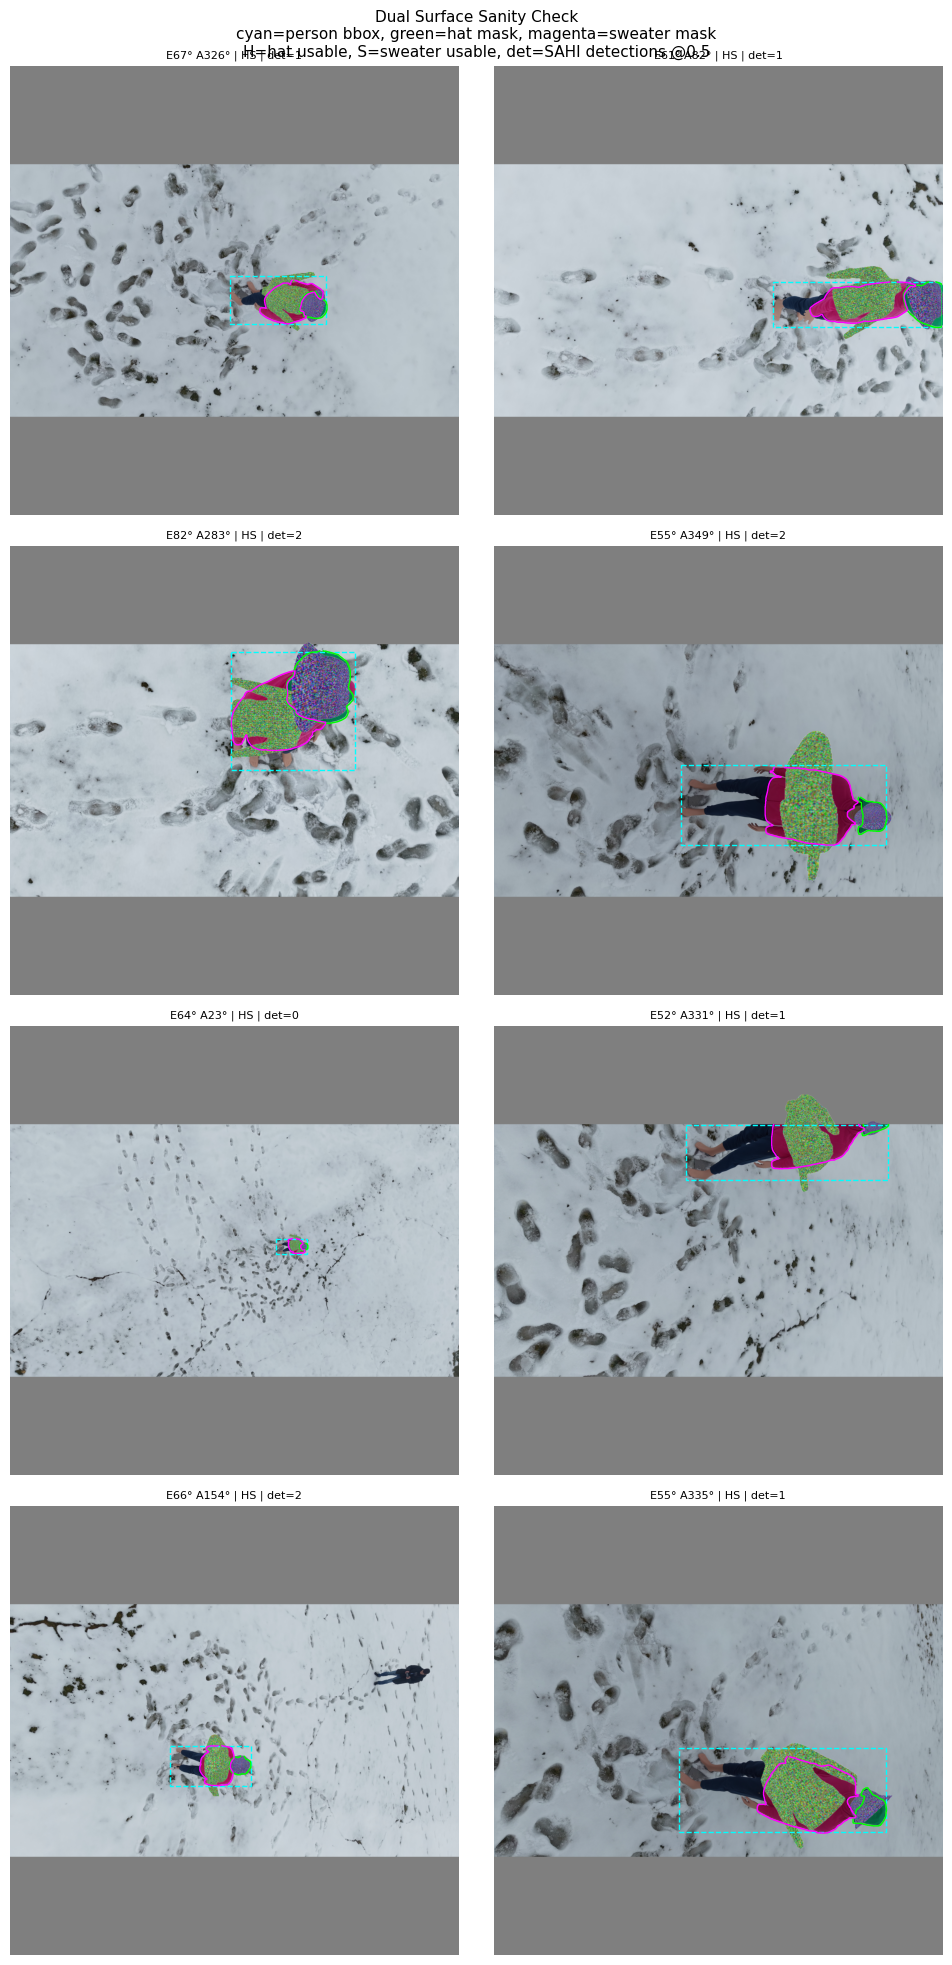

2026-03-18 01:56:03,342 | CHECK: rendered texture should appear INSIDE green (hat) and magenta (sweater) outlines
2026-03-18 01:56:03,344 | CHECK: sweater texture should be behind hat where they overlap
2026-03-18 01:56:03,345 | CHECK: frames marked '-S' should have no sweater texture, '-H' no hat texture
2026-03-18 01:56:03,346 | CHECK: every frame should show det >= 1 (untrained texture shouldn't fool detector)


In [12]:
# ══════════════════════════════════════════════════════════════
# PIPELINE SANITY CHECK — dual surface compositing on real frames
# ══════════════════════════════════════════════════════════════
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

sahi_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path='yolov8m.pt',
    confidence_threshold=0.5,
    device=str(device)
)

logger.info("Sanity check: compositing both surfaces on real frames...")
num_preview = min(8, len(dataset_all))
preview_indices = np.random.choice(len(dataset_all), num_preview, replace=False)

cols = 2
rows = (num_preview + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

with torch.no_grad():
    rand_hat_tex = generator_hat.generate(batch_size=1)
    rand_sw_tex = generator_sweater.generate(batch_size=1)
    
    for i, idx in enumerate(preview_indices):
        sample = dataset_all[idx]
        scene = sample['image'].unsqueeze(0).to(device)
        hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
        sweater_mask = sample['sweater_mask'].unsqueeze(0).to(device)
        elev = sample['elevation'].item()
        azim = sample['azimuth'].item()
        scl = sample['scale'].item()
        hat_ok = sample['hat_usable']
        sw_ok = sample['sweater_usable']
        
        gimbal_yaw_val = dataset_all.frames[idx]['drone']['gimbal_yaw_360']
        bearing_val = dataset_all.frames[idx]['drone']['heading']
        gimbal_pitch_val = dataset_all.frames[idx]['drone']['gimbal_pitch_raw']
        
        rh, ah = renderer_hat.render(
            rand_hat_tex,
            elevation=torch.tensor([elev], device=device),
            scale=torch.tensor([scl], device=device),
            bearing=torch.tensor([bearing_val], device=device),
            gimbal_yaw=torch.tensor([gimbal_yaw_val], device=device),
            gimbal_pitch=torch.tensor([gimbal_pitch_val], device=device))
        
        rs, as_ = renderer_sweater.render(
            rand_sw_tex,
            elevation=torch.tensor([elev], device=device),
            scale=torch.tensor([scl], device=device),
            bearing=torch.tensor([bearing_val], device=device),
            gimbal_yaw=torch.tensor([gimbal_yaw_val], device=device),
            gimbal_pitch=torch.tensor([gimbal_pitch_val], device=device))
        
        # Dual composite
        composite = composite_dual_on_scene(
            scene, hat_mask, sweater_mask,
            rh, ah, rs, as_,
            [hat_ok], [sw_ok])
        
        # SAHI detection
        comp_np = (composite[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        comp_bgr = cv2.cvtColor(comp_np, cv2.COLOR_RGB2BGR)
        tmp_path = f"{CONFIG['output_dir']}/tmp_sanity.png"
        cv2.imwrite(tmp_path, comp_bgr)
        sahi_result = get_sliced_prediction(
            tmp_path, sahi_model,
            slice_height=CONFIG['sahi_slice_size'],
            slice_width=CONFIG['sahi_slice_size'],
            overlap_height_ratio=CONFIG['sahi_overlap'],
            overlap_width_ratio=CONFIG['sahi_overlap'],
            verbose=0,
        )
        n_det = sum(1 for p in sahi_result.object_prediction_list if p.category.id == 0)
        
        # Display
        axes[i].imshow(composite[0].permute(1, 2, 0).cpu())
        
        # Person bbox in cyan
        bbox = sample['person_bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                              linewidth=1, edgecolor='cyan', facecolor='none', linestyle='--')
        axes[i].add_patch(rect)
        
        # Hat mask outline in green
        hat_np = hat_mask[0, 0].cpu().numpy()
        contours, _ = cv2.findContours((hat_np > 0.5).astype(np.uint8),
                                        cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            c = c.squeeze()
            if c.ndim == 2 and len(c) > 2:
                axes[i].plot(c[:, 0], c[:, 1], 'lime', linewidth=1)
        
        # Sweater mask outline in magenta
        sw_np = sweater_mask[0, 0].cpu().numpy()
        contours_sw, _ = cv2.findContours((sw_np > 0.5).astype(np.uint8),
                                           cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours_sw:
            c = c.squeeze()
            if c.ndim == 2 and len(c) > 2:
                axes[i].plot(c[:, 0], c[:, 1], 'magenta', linewidth=1)
        
        # Labels
        usable_str = f"{'H' if hat_ok else '-'}{'S' if sw_ok else '-'}"
        axes[i].set_title(f'E{elev:.0f}° A{azim:.0f}° | {usable_str} | det={n_det}', fontsize=8)
        axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Dual Surface Sanity Check\n'
             'cyan=person bbox, green=hat mask, magenta=sweater mask\n'
             'H=hat usable, S=sweater usable, det=SAHI detections @0.5',
             fontsize=11)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/pipeline_check_dual.png", dpi=150, bbox_inches='tight')
plt.show()

logger.info("CHECK: rendered texture should appear INSIDE green (hat) and magenta (sweater) outlines")
logger.info("CHECK: sweater texture should be behind hat where they overlap")
logger.info("CHECK: frames marked '-S' should have no sweater texture, '-H' no hat texture")
logger.info("CHECK: every frame should show det >= 1 (untrained texture shouldn't fool detector)")

## 12: Ensamble

Ensamble detection

In [ ]:
#Monkey Patching
"""
from ultralytics.nn.modules.block import C2f, Bottleneck
from ultralytics.nn.modules.head import Detect
_orig_c2f = C2f.forward
def _safe_c2f(self, x):
    y = list(self.cv1(x).chunk(2, 1))
    y = [yi.clone() for yi in y]
    for m in self.m:
        y.append(m(y[-1]))
    return self.cv2(torch.cat(y, 1))
C2f.forward = _safe_c2f
_orig_bn = Bottleneck.forward
def _safe_bn(self, x):
    return x.clone() + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))
Bottleneck.forward = _safe_bn
_orig_fh = Detect.forward_head
def _safe_fh(self, x, box_head, cls_head):
    bs = x[0].shape[0]
    boxes = torch.cat([box_head[i](x[i].clone()).reshape(bs, 4 * self.reg_max, -1) for i in range(self.nl)], dim=-1)
    scores = torch.cat([cls_head[i](x[i].clone()).reshape(bs, self.nc, -1) for i in range(self.nl)], dim=-1)
    return dict(boxes=boxes, scores=scores, feats=x)
Detect.forward_head = _safe_fh
"""

class DetectorEnsemble:
    
    def __init__(self, attack_mode='gray', device='cuda', conf_floor=0.001):
        self.device = device
        self.conf_floor = conf_floor
        self.models = {}
        self.weights = {}
        if attack_mode == 'white':
            self.models['yolov8m'] = YOLO('yolov8m.pt')
            self.models['yolov8m'].model.to(device)
            for m in self.models['yolov8m'].model.modules():
                if hasattr(m, 'inplace'):
                    m.inplace = False
                if isinstance(m, nn.SiLU):
                    m.inplace = False
                if isinstance(m, nn.ReLU):
                    m.inplace = False
            self.weights['yolov8m'] = 1.0
        elif attack_mode == 'gray':
            model_configs = [
                ('yolov8s', 0.20),
                ('yolov8m', 0.25),
                ('yolov8l', 0.20),
                ('yolov5m', 0.20),
                ('yolov5l', 0.15),
            ]
            for name, weight in model_configs:
                try:
                    self.models[name] = YOLO(f'{name}.pt')
                    self.models[name].model.to(device)
                    for m in self.models[name].model.modules():
                        if hasattr(m, 'inplace'):
                            m.inplace = False
                        if isinstance(m, nn.SiLU):
                            m.inplace = False
                        if isinstance(m, nn.ReLU):
                            m.inplace = False
                    self.weights[name] = weight
                    logger.info(f"Loaded {name}")
                except Exception as e:
                    logger.warning(f"Failed to load {name}: {e}")
        elif attack_mode == 'black':
            #Add More
            model_configs = [
                ('yolov8m', 0.30),
                ('yolov8l', 0.25),
                ('yolov5l', 0.25),
                ('yolov5m', 0.20),
            ]
            for name, weight in model_configs:
                try:
                    self.models[name] = YOLO(f'{name}.pt')
                    self.models[name].model.to(device)
                    for m in self.models[name].model.modules():
                        if hasattr(m, 'inplace'):
                            m.inplace = False
                        if isinstance(m, nn.SiLU):
                            m.inplace = False
                        if isinstance(m, nn.ReLU):
                            m.inplace = False
                    self.weights[name] = weight
                except Exception as e:
                    logger.warning(f"Failed to load {name}: {e}") 
        #Normalize weights
        total = sum(self.weights.values())
        if total == 0:
            logger.error("No detector models loaded. Cannot proceed.")
            raise RuntimeError("No detector models loaded successfully")
        self.weights = {k: v/total for k, v in self.weights.items()}
        logger.info(f"Detector ensemble ({attack_mode}): {list(self.weights.keys())}")
        
    def compute_loss(self, images, return_detections=False):
        total_loss = 0.0
        all_detections = [] if return_detections else None
        for name, model in self.models.items():
            weight = self.weights[name]
            preds = model.model(images)
            #Use pre-sigmoid logits from the second output
            if isinstance(preds, (list, tuple)) and len(preds) >= 2 and isinstance(preds[1], dict) and 'scores' in preds[1]:
                #preds[1]['scores'] shape: [B, num_classes, num_anchors]
                #Class 0 = person
                person_conf = preds[1]['scores'][:, 0, :]
            elif isinstance(preds, (list, tuple)):
                preds = preds[0]
                if preds.dim() == 3 and preds.shape[1] == 84:
                    person_conf = preds[:, 4, :]
                elif preds.dim() == 3 and preds.shape[2] >= 85:
                    person_conf = preds[..., 4] * preds[..., 5]
                else:
                    logger.warning(f"{name}: unexpected pred shape {preds.shape}, skipping")
                    continue
            elif isinstance(preds, dict):
                person_conf = preds['scores'][:, 0, :]
            else:
                logger.warning(f"{name}: unexpected pred type {type(preds)}, skipping")
                continue
            B = person_conf.shape[0]
            per_image_loss = []
            for b in range(B):
                img_confs = person_conf[b].reshape(-1)
                k = min(25, img_confs.numel())
                top_confs, _ = img_confs.topk(k)
                per_image_loss.append(top_confs.mean())
            model_loss = torch.stack(per_image_loss).mean()
            total_loss = total_loss + weight * model_loss
            if return_detections:
                all_detections.append({'model': name, 'preds': preds.detach() if isinstance(preds, torch.Tensor) else None})
        if return_detections:
            return total_loss, all_detections
        return total_loss
    
    def detect(self, images, conf_threshold=0.5):
        images_np = [(images[i] * 255).byte().permute(1, 2, 0).cpu().numpy() for i in range(images.shape[0])]
        all_results = {}
        for name, model in self.models.items():
            results = model.predict(images_np, conf=self.conf_floor, classes=[0], verbose=False)
            all_results[name] = []
            for r in results:
                if len(r.boxes) > 0:
                    scores = r.boxes.conf.cpu().numpy()
                    boxes = r.boxes.xyxy.cpu().numpy()
                    #Filter by the actual requested threshold
                    keep = scores >= conf_threshold
                    all_results[name].append({'boxes': boxes[keep],'scores': scores[keep]})
                else:
                    all_results[name].append({'boxes': np.array([]),'scores': np.array([])})
        return all_results

#Initialize detector ensemble
detector = DetectorEnsemble(CONFIG['attack_mode'], device, conf_floor=CONFIG['det_conf_floor'])

## 13: Stage 1: Generator Training

Train the Generator

In [ ]:
renderer.training_mode = True

def save_texture(texture_tensor, path):
    img = (texture_tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    cv2.imwrite(str(path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

def save_final_texture(texture_batch, config, path):
    tex = texture_batch[0].detach().cpu().clamp(0, 1)
    out_h = config.get('texture_output_size_h', tex.shape[1])
    out_w = config.get('texture_output_size_w', tex.shape[2])
    tex_up = F.interpolate(tex.unsqueeze(0), size=(out_h, out_w), mode='bilinear', align_corners=False).squeeze(0)
    img = (tex_up.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    cv2.imwrite(str(path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    logger.info(f"Saved final texture: {path} ({out_w}x{out_h}px)")

def export_print_template(texture_batch, mesh_path, config, path):
    save_final_texture(texture_batch, config, path)

def train_stage1(generator, aux_net, detector, dataset, config):
    renderer.training_mode = True
    generator.train()
    aux_net.train()
    opt_g = torch.optim.Adam(generator.parameters(), lr=config['stage1_lr'], betas=(0.5, 0.999))
    opt_aux = torch.optim.Adam(aux_net.parameters(), lr=config['stage1_lr'] * 5, betas=(0.5, 0.999))
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=config['stage1_batch_size'], shuffle=True, num_workers=config['num_workers'], pin_memory=True, persistent_workers=True)
    sahi_configs = config['sahi_train_configs']
    
    logger.info("Starting Stage 1 training (differentiable SAHI)...")
    for epoch in range(config['stage1_epochs']):
        # Progressive frequency bottleneck
        bn_size = get_bottleneck_size(epoch, config)
        epoch_losses = {'total': 0, 'detection': 0, 'tv': 0, 'nps': 0, 'mi': 0}
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{config['stage1_epochs']}")
        for batch_idx, batch in enumerate(pbar):
            actual_batch = batch['image'].shape[0]
            z = torch.randn(actual_batch, config['latent_channels'], config['latent_size'], config['latent_size'], device=device)
            
            #Generate texture with frequency bottleneck
            texture = generator.generate(z)
            texture = frequency_bottleneck(texture, bn_size)
            
            #Render hat
            elevs, azims, scls = [], [], []
            for i in range(texture.shape[0]):
                elev, azim, scl = apply_viewpoint_jitter(
                    batch['elevation'][i].item(), batch['azimuth'][i].item(),
                    batch['scale'][i].item(), config)
                elevs.append(elev)
                azims.append(azim)
                scls.append(scl)
            rendered_hat, alpha = renderer.render(texture,
                elevation=torch.tensor(elevs, dtype=torch.float32, device=device),
                azimuth=torch.tensor(azims, dtype=torch.float32, device=device),
                scale=torch.tensor(scls, dtype=torch.float32, device=device))
            
            #Augmentations on rendered hat
            rendered_hat = patch_cutout(rendered_hat, alpha, config['cutout_prob'], config['cutout_ratio'])
            rendered_hat = add_light_spots(rendered_hat, alpha)
            rendered_hat = add_shadows(rendered_hat, alpha)
            rendered_hat = simulate_printing(rendered_hat)
            
            #Composite onto scene (full 1920x1920)
            scene = batch['image'].to(device)
            hat_mask = batch['hat_mask'].to(device)
            composite = composite_hat_on_scene(scene, hat_mask, rendered_hat, alpha)

            person_bboxes_dev = batch['person_bbox'].to(device)
            composite, person_bboxes_dev = random_translate_composite(composite, person_bboxes_dev, max_shift_ratio=0.4)
            
            #Random SAHI config for this step
            sahi_cfg = _random.choice(sahi_configs)
            #Differentiable SAHI loss (two-pass)
            loss_det = differentiable_sahi_loss(
                composite, person_bboxes_dev, detector, config,
                slice_size=sahi_cfg['slice'], overlap=sahi_cfg['overlap'],
                target_size=config['detector_input_size'])
            
            #Regularization
            loss_tv = total_variation_loss(texture)
            loss_nps = printer_gamut.nps_loss(texture)
            loss_mi = compute_mi_loss(aux_net, texture, z)
            #Total loss
            if epoch < 5:
                loss = (config['lambda_tv'] * loss_tv + 
                       config['lambda_nps'] * loss_nps + 
                       config['lambda_info'] * loss_mi)
            else:
                loss = (loss_det + config['lambda_tv'] * loss_tv + 
                       config['lambda_nps'] * loss_nps + 
                       config['lambda_info'] * loss_mi)
            opt_g.zero_grad()
            opt_aux.zero_grad()
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(aux_net.parameters(), 1.0)
                opt_g.step()
                opt_aux.step()
            epoch_losses['total'] += loss.item() if isinstance(loss, torch.Tensor) else loss
            epoch_losses['detection'] += loss_det.item() if isinstance(loss_det, torch.Tensor) else loss_det
            epoch_losses['tv'] += loss_tv.item()
            epoch_losses['nps'] += loss_nps.item()
            epoch_losses['mi'] += loss_mi.item()
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}" if isinstance(loss, torch.Tensor) else f"{loss:.4f}",
                'det': f"{loss_det.item():.4f}" if isinstance(loss_det, torch.Tensor) else f"{loss_det:.4f}",
                'bn': bn_size,
                'sahi': f"{sahi_cfg['slice']}/{sahi_cfg['overlap']}"
            })
        n_batches = len(dataloader)
        for k in epoch_losses:
            epoch_losses[k] /= n_batches
        logger.info(f"Epoch {epoch+1} - Loss: {epoch_losses['total']:.4f}, "
                    f"Det: {epoch_losses['detection']:.4f}, "
                    f"TV: {epoch_losses['tv']:.4f}, "
                    f"MI: {epoch_losses['mi']:.4f}, "
                    f"Bottleneck: {bn_size}")
        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                sample = generator.generate(batch_size=1)
                sample = frequency_bottleneck(sample, bn_size)
                save_texture(sample[0], f"{config['output_dir']}/texture_epoch{epoch+1}.png")
    
    renderer.training_mode = False
    return generator

## 14: Stage 2: Latent Optimization

Optimize the Latent

In [ ]:
def train_stage2(generator, detector, dataset, config, z_local=None):
    renderer.training_mode = True
    generator.eval()
    
    toroidal = ToroidalLatent(local_size=config['local_latent_size'], crop_size=config['latent_size'], latent_channels=config['latent_channels'], device=device)
    if z_local is not None:
        toroidal.z_local.data = z_local
    optimizer = torch.optim.Adam([
        {'params': toroidal.parameters(), 'lr': config['stage2_lr']},
        {'params': generator.parameters(), 'lr': config['stage2_generator_lr']},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=3333, T_mult=1, eta_min=1e-5)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=config['stage2_batch_size'], shuffle=True, num_workers=config['num_workers'], pin_memory=True, persistent_workers=True)
    data_iter = iter(dataloader)
    sahi_configs = config['sahi_train_configs']
    bn_size = config['freq_bottleneck']['stage2']
    logger.info(f"Starting Stage 2 (differentiable SAHI, bottleneck={bn_size})...")
    best_loss = float('inf')
    best_z_local = toroidal.z_local.data.clone()
    best_generator_state = {k: v.clone() for k, v in generator.state_dict().items()}
    
    pbar = tqdm(range(config['stage2_iterations']), desc="Stage 2")
    for iteration in pbar:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)
        
        actual_batch = batch['image'].shape[0]
        z_canon = toroidal.get_canonical_crop()
        z_crops = z_canon.expand(actual_batch, -1, -1, -1)
        #Generate with frequency bottleneck
        texture = generator.generate(z_crops)
        texture = frequency_bottleneck(texture, bn_size)
        #Render
        elevs, azims, scls = [], [], []
        for i in range(texture.shape[0]):
            elev, azim, scl = apply_viewpoint_jitter(
                batch['elevation'][i].item(), batch['azimuth'][i].item(),
                batch['scale'][i].item(), config)
            elevs.append(elev)
            azims.append(azim)
            scls.append(scl)
        rendered_hat, alpha = renderer.render(texture,
            elevation=torch.tensor(elevs, dtype=torch.float32, device=device),
            azimuth=torch.tensor(azims, dtype=torch.float32, device=device),
            scale=torch.tensor(scls, dtype=torch.float32, device=device))
        
        #Augmentations
        rendered_hat = patch_cutout(rendered_hat, alpha, config['cutout_prob'], config['cutout_ratio'])
        rendered_hat = add_light_spots(rendered_hat, alpha)
        rendered_hat = add_shadows(rendered_hat, alpha)
        rendered_hat = simulate_printing(rendered_hat)
        
        #Composite
        scene = batch['image'].to(device)
        hat_mask = batch['hat_mask'].to(device)
        composite = composite_hat_on_scene(scene, hat_mask, rendered_hat, alpha)

        person_bboxes_dev = batch['person_bbox'].to(device)
        composite, person_bboxes_dev = random_translate_composite(composite, person_bboxes_dev, max_shift_ratio=0.4)
        
        #Random SAHI config
        sahi_cfg = _random.choice(sahi_configs)
        #Differentiable SAHI loss
        loss_det = differentiable_sahi_loss(
            composite, person_bboxes_dev, detector, config,
            slice_size=sahi_cfg['slice'], overlap=sahi_cfg['overlap'],
            target_size=config['detector_input_size'])
        loss_tv = total_variation_loss(texture)
        loss_nps = printer_gamut.nps_loss(texture)
        loss = loss_det + config['lambda_tv'] * loss_tv + config['lambda_nps'] * loss_nps
        optimizer.zero_grad()
        if isinstance(loss, torch.Tensor) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(toroidal.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        loss_val = loss.item() if isinstance(loss, torch.Tensor) else loss
        if loss_val < best_loss:
            best_loss = loss_val
            best_z_local = toroidal.z_local.data.clone()
            best_generator_state = {k: v.clone() for k, v in generator.state_dict().items()}
        pbar.set_postfix({
            'loss': f"{loss_val:.4f}", 'best': f"{best_loss:.4f}",
            'det': f"{loss_det.item():.4f}", 'tv': f"{loss_tv.item():.4f}",
            'lr': f"{scheduler.get_last_lr()[0]:.6f}",
            'sahi': f"{sahi_cfg['slice']}/{sahi_cfg['overlap']}"
        })
        if (iteration + 1) % 500 == 0:
            with torch.no_grad():
                z_canon = toroidal.get_canonical_crop()
                sample_texture = generator.generate(z_canon)
                sample_texture = frequency_bottleneck(sample_texture, bn_size)
                save_texture(sample_texture[0], f"{config['output_dir']}/texture_stage2_iter{iteration+1}.png")
                logger.info(f"Iter {iteration+1}: loss={loss_val:.4f}, det={loss_det.item():.4f}")
    
    #Restore best
    logger.info(f"Stage 2 complete. Best loss: {best_loss:.4f}")
    toroidal.z_local.data = best_z_local
    generator.load_state_dict(best_generator_state)
    with torch.no_grad():
        z_canon = toroidal.get_canonical_crop()
        final_texture = generator.generate(z_canon)
        final_texture = frequency_bottleneck(final_texture, bn_size)
    save_final_texture(final_texture, config, f"{config['output_dir']}/final_texture.png")
    torch.save({
        'z_local': best_z_local,
        'generator': generator.state_dict(),
    }, f"{config['output_dir']}/stage2_final.pth")
    renderer.training_mode = False
    return best_z_local, final_texture

## 15: Evaluation

See how we did

In [ ]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import shutil

def evaluate_and_visualize(generator, detector, dataset, z_local, config):

    renderer.training_mode = False
    
    generator.eval()
    toroidal_eval = ToroidalLatent(
        local_size=config['local_latent_size'],
        crop_size=config['latent_size'],
        latent_channels=config['latent_channels'],
        device=device
    )
    toroidal_eval.z_local.data = z_local
    with torch.no_grad():
        z_canon = toroidal_eval.get_canonical_crop()
        best_texture = generator.generate(z_canon)
    total_frames = len(dataset)
    tmp_dir = Path(config['output_dir']) / 'eval_tmp'
    tmp_dir.mkdir(exist_ok=True)
    
    #PHASE 1: Write all baseline + attack images to disk
    logger.info("Writing baseline and attack images...")
    frame_meta = []  # Store per-frame info for later
    with torch.no_grad():
        for idx in range(total_frames):
            sample = dataset[idx]
            scene = sample['image'].unsqueeze(0).to(device)
            hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
            elev = sample['elevation'].item()
            azim = sample['azimuth'].item()
            scl = sample['scale'].item()
            bbox = sample['person_bbox']
            #Baseline
            baseline_np = (scene[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(str(tmp_dir / f'baseline_{idx}.png'), cv2.cvtColor(baseline_np, cv2.COLOR_RGB2BGR))
            #Attack composite
            rendered_hat, alpha = renderer.render(
                best_texture,
                elevation=torch.tensor([elev], device=device),
                azimuth=torch.tensor([azim], device=device),
                scale=torch.tensor([scl], device=device)
            )
            composite = composite_hat_on_scene(scene, hat_mask, rendered_hat, alpha)
            attack_np = (composite[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(str(tmp_dir / f'attack_{idx}.png'), cv2.cvtColor(attack_np, cv2.COLOR_RGB2BGR))
            frame_meta.append({
                'idx': idx,
                'elev': elev,
                'azim': azim,
                'scale': scl,
                'bbox': bbox,
            })
            if idx % 40 == 0:
                logger.info(f"  Writing images {idx}/{total_frames}...")
    
    #PHASE 2: CROP-BASED EVALUATION
    logger.info("\n" + "=" * 60)
    logger.info("CROP-BASED EVALUATION")
    logger.info("=" * 60)
    crop_baseline_det = 0
    crop_attack_det = 0
    crop_conf_drops = []
    crop_frame_results = []
    with torch.no_grad():
        for idx in range(total_frames):
            sample = dataset[idx]
            scene = sample['image'].unsqueeze(0).to(device)
            hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
            bbox = sample['person_bbox'].unsqueeze(0).to(device)
            elev = sample['elevation'].item()
            azim = sample['azimuth'].item()
            scl = sample['scale'].item()
            #Baseline crop
            clean_crop = crop_to_person(scene, bbox, target_size=config['detector_input_size'])
            clean_results = detector.detect(clean_crop, conf_threshold=0.25)
            clean_found = False
            clean_conf = 0.0
            for name, dets in clean_results.items():
                if len(dets[0]['scores']) > 0:
                    clean_found = True
                    clean_conf = float(dets[0]['scores'].max())
                break
            if clean_found:
                crop_baseline_det += 1
            #Attacked crop
            rendered_hat, alpha = renderer.render(
                best_texture,
                elevation=torch.tensor([elev], device=device),
                azimuth=torch.tensor([azim], device=device),
                scale=torch.tensor([scl], device=device)
            )
            composite = composite_hat_on_scene(scene, hat_mask, rendered_hat, alpha)
            attack_crop = crop_to_person(composite, bbox, target_size=config['detector_input_size'])
            attack_results = detector.detect(attack_crop, conf_threshold=0.25)
            attack_found = False
            attack_conf = 0.0
            for name, dets in attack_results.items():
                if len(dets[0]['scores']) > 0:
                    attack_found = True
                    attack_conf = float(dets[0]['scores'].max())
                break
            if attack_found:
                crop_attack_det += 1
            if clean_found:
                crop_conf_drops.append(clean_conf - attack_conf)
            crop_frame_results.append({
                'frame_idx': idx,
                'baseline_detected': clean_found,
                'baseline_conf': round(clean_conf, 3),
                'attack_detected': attack_found,
                'attack_conf': round(attack_conf, 3),
                'suppressed': clean_found and not attack_found,
            })
    crop_suppressed = crop_baseline_det - crop_attack_det
    crop_asr = crop_suppressed / crop_baseline_det if crop_baseline_det > 0 else 0.0
    crop_avg_drop = np.mean(crop_conf_drops) if crop_conf_drops else 0.0
    logger.info(f"  Baseline detected:  {crop_baseline_det}/{total_frames} ({crop_baseline_det/total_frames:.1%})")
    logger.info(f"  Attack detected:    {crop_attack_det}/{total_frames}")
    logger.info(f"  Suppressed (ASR):   {crop_suppressed}/{crop_baseline_det} ({crop_asr:.1%})")
    logger.info(f"  Avg conf drop:      {crop_avg_drop:.3f}")
    
    #PHASE 3: MULTI-CONFIG SAHI + FULLFRAME EVALUATION
    eval_sahi_model = AutoDetectionModel.from_pretrained(
        model_type='yolov8',
        model_path='yolov8m.pt',
        confidence_threshold=0.25,
        device=str(device)
    )
    eval_configs = []
    for sl in [480, 640, 768, 960, 1280]:
        for ov in [0.0, 0.15, 0.30]:
            eval_configs.append({
                'name': f'sahi_{sl}_{ov:.2f}',
                'method': 'sahi', 'slice': sl, 'overlap': ov
            })
    #Add fullframe configs
    eval_configs.append({'name': 'fullframe_640', 'method': 'fullframe', 'resize': 640})
    eval_configs.append({'name': 'fullframe_1280', 'method': 'fullframe', 'resize': 1280})
    crop_thresholds = {}
    for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
        base_det = sum(1 for r in crop_frame_results if r['baseline_conf'] >= thresh)
        suppressed = sum(1 for r in crop_frame_results 
                        if r['baseline_conf'] >= thresh and r['attack_conf'] < thresh)
        asr_t = suppressed / base_det if base_det > 0 else 0.0
        still_det = [r for r in crop_frame_results 
                    if r['baseline_conf'] >= thresh and r['attack_conf'] >= thresh]
        avg_drop = np.mean([r['baseline_conf'] - r['attack_conf'] for r in still_det]) if still_det else 0.0
        crop_thresholds[thresh] = {
            'baseline_detected': base_det,
            'suppressed': suppressed,
            'asr': asr_t,
            'avg_conf_drop': avg_drop,
        }
    all_results = {
        'crop_640': {
            'thresholds': crop_thresholds,
            'frame_results': crop_frame_results,
        }
    }
    #Store per-frame results for the hardest config (sahi_960_0.30) for visualization
    sahi_hard_frame_results = []
    for ec in eval_configs:
        logger.info(f"\n--- Evaluating: {ec['name']} ---")
        baseline_detected = 0
        attacked_detected = 0
        conf_drops = []
        this_frame_results = []
        for idx in range(total_frames):
            baseline_path = str(tmp_dir / f'baseline_{idx}.png')
            attack_path = str(tmp_dir / f'attack_{idx}.png')
            if ec['method'] == 'sahi':
                b_result = get_sliced_prediction(
                    baseline_path, eval_sahi_model,
                    slice_height=ec['slice'], slice_width=ec['slice'],
                    overlap_height_ratio=ec['overlap'],
                    overlap_width_ratio=ec['overlap'],
                    verbose=0,
                )
                a_result = get_sliced_prediction(
                    attack_path, eval_sahi_model,
                    slice_height=ec['slice'], slice_width=ec['slice'],
                    overlap_height_ratio=ec['overlap'],
                    overlap_width_ratio=ec['overlap'],
                    verbose=0,
                )
                b_persons = [p for p in b_result.object_prediction_list if p.category.id == 0]
                a_persons = [p for p in a_result.object_prediction_list if p.category.id == 0]
                b_found = len(b_persons) > 0
                a_found = len(a_persons) > 0
                b_conf = max(p.score.value for p in b_persons) if b_persons else 0.0
                a_conf = max(p.score.value for p in a_persons) if a_persons else 0.0
            elif ec['method'] == 'fullframe':
                b_img = cv2.imread(baseline_path)
                a_img = cv2.imread(attack_path)
                sz = ec['resize']
                b_resized = cv2.resize(b_img, (sz, sz))
                a_resized = cv2.resize(a_img, (sz, sz))
                yolo_model = detector.models[list(detector.models.keys())[0]]
                b_det = yolo_model.predict(b_resized, conf=0.25, classes=[0], verbose=False)
                a_det = yolo_model.predict(a_resized, conf=0.25, classes=[0], verbose=False)
                b_found = len(b_det[0].boxes) > 0
                a_found = len(a_det[0].boxes) > 0
                b_conf = float(b_det[0].boxes.conf.max()) if b_found else 0.0
                a_conf = float(a_det[0].boxes.conf.max()) if a_found else 0.0
            if b_found:
                baseline_detected += 1
            if a_found:
                attacked_detected += 1
            if b_found:
                conf_drops.append(b_conf - a_conf)
            this_frame_results.append({
                'frame_idx': idx,
                'baseline_detected': b_found,
                'baseline_conf': round(b_conf, 3),
                'attack_detected': a_found,
                'attack_conf': round(a_conf, 3),
                'suppressed': b_found and not a_found,
            })
        #Compute ASR at multiple thresholds
        thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
        threshold_results = {}
        for thresh in thresholds:
            base_det = sum(1 for r in this_frame_results if r['baseline_conf'] >= thresh)
            suppressed = sum(1 for r in this_frame_results if r['baseline_conf'] >= thresh and r['attack_conf'] < thresh)
            asr = suppressed / base_det if base_det > 0 else 0.0
            still_det = [r for r in this_frame_results if r['baseline_conf'] >= thresh and r['attack_conf'] >= thresh]
            avg_drop = np.mean([r['baseline_conf'] - r['attack_conf'] for r in still_det]) if still_det else 0.0
            threshold_results[thresh] = {
                'baseline_detected': base_det,
                'suppressed': suppressed,
                'asr': asr,
                'avg_conf_drop': avg_drop,
            }
        all_results[ec['name']] = {
            'thresholds': threshold_results,
            'frame_results': this_frame_results,
        }
        if ec['name'] == 'sahi_960_0.30':
            sahi_hard_frame_results = this_frame_results
        #Log the 0.5 result as the headline
        t5 = threshold_results[0.5]
        logger.info(f"  Baseline@0.5: {t5['baseline_detected']}/{total_frames}  "
                    f"Suppressed: {t5['suppressed']}/{t5['baseline_detected']}  "
                    f"ASR: {t5['asr']:.1%}  Drop: {t5['avg_conf_drop']:.3f}")
    
    #RESULTS SUMMARY TABLE
    config_names = list(all_results.keys())
    logger.info("\n" + "=" * 85)
    header = f"{'Config':<20}"
    for t in thresholds:
        header += f" {'ASR@'+str(t):>10}"
    logger.info(header)
    logger.info("-" * 85)
    for name in config_names:
        row = f"{name:<20}"
        for t in thresholds:
            r = all_results[name]['thresholds'].get(t, {})
            asr = r.get('asr', 0.0)
            row += f" {asr:>9.1%}"
        logger.info(row)
    logger.info("=" * 85)

    #VISUALIZATION: SAHI ASR HEATMAP
    slice_sizes = [480, 640, 768, 960, 1280]
    overlaps = [0.0, 0.15, 0.30]
    heatmap_data = np.zeros((len(slice_sizes), len(overlaps)))
    for si, sl in enumerate(slice_sizes):
        for oi, ov in enumerate(overlaps):
            key = f'sahi_{sl}_{ov:.2f}'
            if key in all_results:
                heatmap_data[si, oi] = all_results[key]['thresholds'].get(0.5, {}).get('asr', 0.0)
    
    fig_hm, ax_hm = plt.subplots(1, 1, figsize=(8, 6))
    im = ax_hm.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax_hm.set_xticks(range(len(overlaps)))
    ax_hm.set_xticklabels([f'{o:.0%}' for o in overlaps])
    ax_hm.set_yticks(range(len(slice_sizes)))
    ax_hm.set_yticklabels([str(s) for s in slice_sizes])
    ax_hm.set_xlabel('Overlap')
    ax_hm.set_ylabel('Slice Size')
    ax_hm.set_title('ASR@0.5 Heatmap: SAHI Configuration Space')
    #Annotate cells
    for si in range(len(slice_sizes)):
        for oi in range(len(overlaps)):
            val = heatmap_data[si, oi]
            ax_hm.text(oi, si, f'{val:.1%}', ha='center', va='center',
                      color='black' if val > 0.3 else 'white', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax_hm, label='ASR')
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/eval_sahi_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #VISUALIZATION 1: ASR + Conf Drop Bar Charts
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
    #ASR grouped bars
    x = np.arange(len(config_names))
    width = 0.15
    for i, thresh in enumerate(thresholds):
        asrs = []
        for name in config_names:
            r = all_results[name]['thresholds'].get(thresh, {})
            asrs.append(r.get('asr', 0.0))
        offset = (i - len(thresholds) / 2 + 0.5) * width
        bars = axes1[0].bar(x + offset, asrs, width, label=f'conf={thresh}')
    axes1[0].set_xticks(x)
    axes1[0].set_xticklabels(config_names, rotation=25, ha='right', fontsize=9)
    axes1[0].set_ylabel('ASR')
    axes1[0].set_title('Attack Success Rate by Config & Threshold')
    axes1[0].set_ylim(0, 1)
    axes1[0].legend(fontsize=8)
    #Conf drop at 0.5 (single bar per config)
    drops = []
    for name in config_names:
        r = all_results[name]['thresholds'].get(0.5, {})
        drops.append(r.get('avg_conf_drop', 0.0))
    colors = ['#9C27B0', '#2196F3', '#1976D2', '#FF9800', '#F57C00'][:len(config_names)]
    axes1[1].bar(range(len(config_names)), drops, color=colors)
    axes1[1].set_xticks(range(len(config_names)))
    axes1[1].set_xticklabels(config_names, rotation=25, ha='right', fontsize=9)
    axes1[1].set_ylabel('Avg Confidence Drop')
    axes1[1].set_title('Confidence Reduction @ 0.5 Threshold')
    for i, v in enumerate(drops):
        axes1[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/eval_multi_config.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #VISUALIZATION 2: Success/Failure Grid (SAHI 0.30)
    fig2, axes2 = plt.subplots(2, 5, figsize=(25, 10))
    failed = sorted([r for r in sahi_hard_frame_results if r['baseline_detected'] and r['attack_detected']], key=lambda r: -r['attack_conf'])[:5]
    for i, r in enumerate(failed):
        img = cv2.imread(str(tmp_dir / f'attack_{r["frame_idx"]}.png'))
        axes2[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes2[0, i].set_title(f'FAIL #{r["frame_idx"]}\nbase={r["baseline_conf"]:.2f} atk={r["attack_conf"]:.2f}', fontsize=9)
        axes2[0, i].axis('off')
    for j in range(len(failed), 5):
        axes2[0, j].axis('off')
    axes2[0, 0].set_ylabel('Attack Failed (SAHI 0.30)', fontsize=12)
    succeeded = sorted([r for r in sahi_hard_frame_results if r['suppressed']], key=lambda r: -r['baseline_conf'])[:5]
    for i, r in enumerate(succeeded):
        img = cv2.imread(str(tmp_dir / f'attack_{r["frame_idx"]}.png'))
        axes2[1, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes2[1, i].set_title(f'SUCCESS #{r["frame_idx"]}\nbase={r["baseline_conf"]:.2f} → suppressed', fontsize=9)
        axes2[1, i].axis('off')
    for j in range(len(succeeded), 5):
        axes2[1, j].axis('off')
    axes2[1, 0].set_ylabel('Attack Succeeded (SAHI 0.30)', fontsize=12)
    sahi_t5 = all_results.get('sahi_960_0.30', {}).get('thresholds', {}).get(0.5, {})
    sahi_asr = sahi_t5.get('asr', 0.0)
    sahi_sup = sahi_t5.get('suppressed', 0)
    sahi_base = sahi_t5.get('baseline_detected', 0)
    fig2.suptitle(f'SAHI 0.30 Evaluation: ASR = {sahi_asr:.1%} ({sahi_sup}/{sahi_base})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/eval_sahi_detail.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #VISUALIZATION 3: Hat Renders — Key Angles Only
    #6 meaningful views: overhead, near-overhead, 4 side angles
    hat_views = [
        (90, 0, 'Directly Above (90°)'),
        (85, 0, 'Drone View (85°, front)'),
        (85, 90, 'Drone View (85°, side)'),
        (80, 0, 'Angled (80°, front)'),
        (75, 45, 'Angled (75°, 45°)'),
        (60, 0, 'Low Angle (60°, front)'),
    ]
    fig3, axes3 = plt.subplots(1, len(hat_views), figsize=(len(hat_views) * 3, 3.5))
    with torch.no_grad():
        for i, (elev, azim, title) in enumerate(hat_views):
            rendered, alpha = renderer.render(best_texture, elevation=elev, azimuth=azim, scale=1.0)
            # Black background — no washed out colors
            vis = rendered * alpha
            axes3[i].imshow(vis[0].permute(1, 2, 0).cpu().clamp(0, 1))
            axes3[i].set_title(title, fontsize=8)
            axes3[i].axis('off')
    fig3.suptitle('Adversarial Hat — Key Viewpoints', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_hat_angles.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #VISUALIZATION 4: Composited Frames (ONLY where baseline detects)
    # Find frames where crop-based baseline detects, sample up to 4
    baseline_ok_indices = [r['frame_idx'] for r in crop_frame_results if r['baseline_detected']]
    if len(baseline_ok_indices) > 4:
        # Pick evenly spaced from the baseline-detected set
        step = len(baseline_ok_indices) // 4
        show_indices = [baseline_ok_indices[i * step] for i in range(4)]
    else:
        show_indices = baseline_ok_indices[:4]
    num_show = len(show_indices)
    if num_show > 0:
        fig4, axes4 = plt.subplots(num_show, 4, figsize=(20, num_show * 5))
        if num_show == 1:
            axes4 = axes4[np.newaxis, :]
        col_titles = ['Original Scene', 'With Adversarial Hat', 'Clean Crop + Detections', 'Attacked Crop + Detections']
        with torch.no_grad():
            for row, idx in enumerate(show_indices):
                sample = dataset[idx]
                scene = sample['image'].unsqueeze(0).to(device)
                hat_mask = sample['hat_mask'].unsqueeze(0).to(device)
                bbox = sample['person_bbox'].unsqueeze(0).to(device)
                elev = sample['elevation'].item()
                azim = sample['azimuth'].item()
                scl = sample['scale'].item()
                rendered_hat, alpha = renderer.render(
                    best_texture,
                    elevation=torch.tensor([elev], device=device),
                    azimuth=torch.tensor([azim], device=device),
                    scale=torch.tensor([scl], device=device)
                )
                composite = composite_hat_on_scene(scene, hat_mask, rendered_hat, alpha)
                clean_crop = crop_to_person(scene, bbox, target_size=config['detector_input_size'])
                attack_crop = crop_to_person(composite, bbox, target_size=config['detector_input_size'])
                
                results_clean = detector.detect(clean_crop, conf_threshold=0.3)
                results_atk = detector.detect(attack_crop, conf_threshold=0.3)
                #Col 0: Original
                axes4[row, 0].imshow(scene[0].permute(1, 2, 0).cpu())
                #Col 1: With hat
                axes4[row, 1].imshow(composite[0].permute(1, 2, 0).cpu())
                #Col 2: Clean crop + detections
                axes4[row, 2].imshow(clean_crop[0].permute(1, 2, 0).cpu().numpy())
                n_clean = 0
                for name, dets in results_clean.items():
                    for box in dets[0]['boxes']:
                        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='lime', facecolor='none')
                        axes4[row, 2].add_patch(rect)
                    n_clean = len(dets[0]['boxes'])
                    break
                #Col 3: Attacked crop + detections
                axes4[row, 3].imshow(attack_crop[0].permute(1, 2, 0).cpu().numpy())
                n_atk = 0
                for name, dets in results_atk.items():
                    for box in dets[0]['boxes']:
                        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='red', facecolor='none')
                        axes4[row, 3].add_patch(rect)
                    n_atk = len(dets[0]['boxes'])
                    break
                #Get this frame's crop result for annotation
                cr = crop_frame_results[idx]
                for j in range(4):
                    axes4[row, j].axis('off')
                if row == 0:
                    for j, t in enumerate(col_titles):
                        axes4[0, j].set_title(t, fontsize=10)
                axes4[row, 2].set_title(f'Clean ({n_clean} det, conf={cr["baseline_conf"]:.2f})', fontsize=9)
                axes4[row, 3].set_title(f'Attacked ({n_atk} det, conf={cr["attack_conf"]:.2f})', fontsize=9)
        fig4.suptitle(f'Attack Visualization — Baseline-Detected Frames Only (crop ASR={crop_asr:.1%})', fontsize=13)
        plt.tight_layout()
        plt.savefig(f"{config['output_dir']}/viz_composites.png", dpi=150, bbox_inches='tight')
        plt.show()
    
    #VISUALIZATION 5: Texture + Print Preview (fixed)
    fig5, axes5 = plt.subplots(1, 3, figsize=(16, 5))
    #Raw texture at native 288×288
    axes5[0].imshow(best_texture[0].permute(1, 2, 0).cpu())
    axes5[0].set_title(f'Adversarial Texture ({config["texture_size"]}×{config["texture_size"]})', fontsize=10)
    axes5[0].axis('off')
    #Print preview: show full texture at native res with DPI annotation
    #Don't upscale — just show the 288×288 with print size info overlay
    out_h = config.get('texture_output_size_h', 1024)
    out_w = config.get('texture_output_size_w', 1024)
    phys_w, phys_h = config.get('physical_size_inches', (10, 10))
    axes5[1].imshow(best_texture[0].permute(1, 2, 0).cpu())
    axes5[1].set_title(f'Print Layout\n{phys_w:.1f}×{phys_h:.1f}" @ {config["printer"]["dpi"]} DPI → {out_w}×{out_h}px', fontsize=9)
    axes5[1].axis('off')
    #On hat at drone view
    with torch.no_grad():
        rendered_85, alpha_85 = renderer.render(best_texture, elevation=85, azimuth=0, scale=1.0)
    hat_vis = rendered_85 * alpha_85  # Black background
    axes5[2].imshow(hat_vis[0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes5[2].set_title('On Hat (85° overhead)', fontsize=10)
    axes5[2].axis('off')
    plt.tight_layout()
    plt.savefig(f"{config['output_dir']}/viz_texture_print.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #SAVE JSON
    eval_output = {
        'summary': {},
        'crop_per_frame': crop_frame_results,
    }
    for name, data in all_results.items():
        eval_output['summary'][name] = data['thresholds']
    with open(f"{config['output_dir']}/eval_results.json", 'w') as f:
        json.dump(eval_output, f, indent=2, default=str)
    
    #Cleanup temp images
    shutil.rmtree(tmp_dir, ignore_errors=True)
    logger.info(f"\nAll results saved to {config['output_dir']}/")
    return {0.5: all_results.get('sahi_960_0.30', {}).get('thresholds', {}).get(0.5, {}).get('asr', 0.0)}

## 16: Main

Bring it all together

In [ ]:
def main():
    #Initialize models
    logger.info("Initializing models...")
    generator = FCNGenerator(latent_channels=CONFIG['latent_channels'], latent_size=CONFIG['latent_size']).to(device)
    aux_net = AuxiliaryNetwork(latent_channels=CONFIG['latent_channels']).to(device)
    logger.info(f"Generator params: {sum(p.numel() for p in generator.parameters()):}")
    logger.info(f"Auxiliary params: {sum(p.numel() for p in aux_net.parameters()):}")
    
    #Stage 1: Train generator
    logger.info("="*50)
    logger.info("STAGE 1: Generator Training")
    logger.info("="*50)
    generator = train_stage1(generator, aux_net, detector, dataset, CONFIG)
    
    #Stage 2: Optimize latent
    logger.info("="*50)
    logger.info("STAGE 2: Latent Optimization")
    logger.info("="*50)
    best_z_local, final_texture = train_stage2(generator, detector, dataset, CONFIG)
    
    #Evaluation + Visualization (combined)
    logger.info("="*50)
    logger.info("EVALUATION & VISUALIZATION")
    logger.info("="*50)
    asr_results = evaluate_and_visualize(generator, detector, dataset, best_z_local, CONFIG)
    export_print_template(final_texture, CONFIG['mesh_path'], CONFIG, f"{CONFIG['output_dir']}/print_template.png")
    
    #Final visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    #Final texture
    axes[0].imshow(final_texture[0].permute(1, 2, 0).cpu())
    axes[0].set_title('Final Adversarial Texture')
    axes[0].axis('off')
    #Rendered examples
    with torch.no_grad():
        toroidal_viz = ToroidalLatent(
            local_size=CONFIG['local_latent_size'],
            crop_size=CONFIG['latent_size'],
            latent_channels=CONFIG['latent_channels'],
            device=device
        )
        toroidal_viz.z_local.data = best_z_local
        z_canon = toroidal_viz.get_canonical_crop()
        viz_texture = generator.generate(z_canon)
        rendered, alpha = renderer.render(viz_texture, 85, 45, 1.0)
    axes[1].imshow(rendered[0].permute(1, 2, 0).cpu())
    axes[1].set_title('Rendered Hat (85°, 45°)')
    axes[1].axis('off')
    
    #ASR plot
    thresholds = list(asr_results.keys())
    values = [asr_results[t] for t in thresholds]
    axes[2].bar(range(len(thresholds)), values)
    axes[2].set_xticks(range(len(thresholds)))
    axes[2].set_xticklabels([f'{t}' for t in thresholds])
    axes[2].set_xlabel('Confidence Threshold')
    axes[2].set_ylabel('Attack Success Rate')
    axes[2].set_title('ASR vs Threshold')
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/final_results.png", dpi=150)
    plt.show()
    logger.info("Training complete!")
    logger.info(f"Final texture saved to: {CONFIG['output_dir']}/final_texture.png")
    return generator, best_z_local, final_texture

#Run if this is the main notebook
if __name__ == "__main__":
    generator, z_local, texture = main()